# Project for the Programming for Data Analytics Module

### Author: Kyra Menai Hamilton

Import the packages

Import the dataset

clean the dataset

Project specifications:
https://vlegalwaymayo.atu.ie/pluginfile.php/1804303/mod_resource/content/2/Project%20Description.pdf

Analysis of Data

1. Change in overall aforestation between the initial year recorded and present day
2. Which county has had the most aforestation?
3. Has there been a change in the largest conributor to aforestation? Plot over time.
4. From the total aforestation in a specific year, is broadleaf or conifer the largest proportion of planted trees? Plot
5. Are there differences in the species type planted depending on the forest owner? Make pie plot per type for proportion comparison? - could do a t-test type thing for p value.

## Packages

In [205]:
# import the modules needed for analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import os

## Ensuring File readability

In [206]:
# Set global font sizes for better readability
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

## Importing Data

saving to csv ref:
https://realpython.com/python-csv/
https://docs.python.org/3/library/csv.html
https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

In [207]:
# Load the data from the CSO API and save the dataset as a CSV file
url = "https://ws.cso.ie/public/api.jsonrpc?data=%7B%22jsonrpc%22:%222.0%22,%22method%22:%22PxStat.Data.Cube_API.ReadDataset%22,%22params%22:%7B%22class%22:%22query%22,%22id%22:%5B%5D,%22dimension%22:%7B%7D,%22extension%22:%7B%22pivot%22:null,%22codes%22:false,%22language%22:%7B%22code%22:%22en%22%7D,%22format%22:%7B%22type%22:%22CSV%22,%22version%22:%221.0%22%7D,%22matrix%22:%22AFA01%22%7D,%22version%22:%222.0%22%7D%7D"
response = requests.get(url)
json_data = response.json()
csv_string = json_data['result']
data = pd.read_csv(io.StringIO(csv_string))
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.getcwd()  # For Jupyter notebooks
csv_path = os.path.join(script_dir, 'pfda_data.csv')
data.to_csv(csv_path, index=False)
# note if saved successfully, a file named 'pfda_data.csv' will appear in the working directory

## Ensuring Folders are ready for outputs

In [208]:
# Create a subfolder for outputs
outputs_dir = os.path.join(script_dir, 'outputs')
os.makedirs(outputs_dir, exist_ok=True)

# Create a subfolder for basic statistical analysis
basic_analysis_dir = os.path.join(script_dir, 'basic_statistical_analysis')
os.makedirs(basic_analysis_dir, exist_ok=True)

## Reading, Cleaning, Drop Rows - Checking the Data

ref: https://realpython.com/python-data-cleaning-numpy-pandas/
https://www.w3schools.com/python/pandas/pandas_cleaning.asp

In [209]:
# Read the dataset
data = pd.read_csv(csv_path)
# Display the first few rows of the dataset
print(data.head())

# Now to clean the dataset
# Check for missing values
print(data.isnull().sum())

# Drop rows with missing values
data = data.dropna()
# Verify that there are no more missing values
print(data.isnull().sum())
# Display data types of each column
print(data.dtypes)

# For now I think the data types are fine, but if needed we can convert them later.

      Statistic Label  Year      County              Species  \
0  Afforestation Area  2007  Co. Carlow  Total Afforestation   
1  Afforestation Area  2007  Co. Carlow  Total Afforestation   
2  Afforestation Area  2007  Co. Carlow  Total Afforestation   
3  Afforestation Area  2007  Co. Carlow  Total Afforestation   
4  Afforestation Area  2007  Co. Carlow            Broadleaf   

          Forest Owner      UNIT  VALUE  
0  Total Afforestation  Hectares   43.0  
1               Farmer  Hectares   43.0  
2           Non-Farmer  Hectares    NaN  
3        Public Sector  Hectares    NaN  
4  Total Afforestation  Hectares   17.0  
Statistic Label       0
Year                  0
County                0
Species               0
Forest Owner          0
UNIT                  0
VALUE              1574
dtype: int64
Statistic Label    0
Year               0
County             0
Species            0
Forest Owner       0
UNIT               0
VALUE              0
dtype: int64
Statistic Label     ob

## Basic Summary Statistics

Summary Stats Basics:
https://realpython.com/python-statistics/
https://snakebear.science/08-Statistics/08_1_Basic_Statistics_Descriptives.html

In [210]:
# Basic Data Exploration
# Summary Statistics for value vs county vs year
summary_stats = data.groupby(['County', 'Year'])['VALUE'].describe()
print(summary_stats)
# Save summary statistics to a CSV file
summary_stats_path = os.path.join(basic_analysis_dir, 'summary_statistics.csv')
summary_stats.to_csv(summary_stats_path)

                 count         mean          std    min     25%     50%  \
County     Year                                                           
Co. Carlow 2007    6.0    28.333333    11.910779   17.0   19.00    25.0   
           2008    6.0    32.666667    18.118131   10.0   17.25    39.0   
           2009    6.0    31.333333    12.209286   22.0   22.75    25.0   
           2010    9.0    44.555556    37.779330    0.0    3.00    46.0   
           2011    8.0    10.625000     8.534593    2.0    2.75    10.5   
...                ...          ...          ...    ...     ...     ...   
Ireland    2019    9.0  1577.777778  1065.862535  366.0  893.00  1292.0   
           2020    9.0  1081.888889   752.348065  180.0  579.00   819.0   
           2021    9.0   896.111111   640.827677  133.0  360.00   829.0   
           2022   12.0   757.750000   723.229013    0.0  182.25   602.5   
           2023   12.0   550.500000   478.518642    1.0  263.00   448.5   

                     75%

## Basic Data Analysis

In [211]:
# Look at interesting statistics findings for the counties and write output to a markdown (.md) file.
with open(os.path.join(basic_analysis_dir, "basic_analysis.md"), "w") as file:
    print("# Basic Statistical Analysis on Ireland Afforestation Data", file=file)
    print("\n***Author: Kyra Menai Hamilton***", file=file)
    print("\n## Summary", file=file)
    summary_text = (
        print("\n## Interesting Statistics Findings for Counties \n", file=file)
    )
    print("\n1. Average VALUE per county (excluding Ireland for county-specific analysis)", file=file)
    counties_data = data[data['County'] != 'Ireland']
    avg_value_per_county = counties_data.groupby('County')['VALUE'].mean().sort_values(ascending=False)
    print(avg_value_per_county.head(10).to_markdown(), file=file)
    avg_value_path = os.path.join(basic_analysis_dir, 'avg_value_per_county.csv')
    avg_value_per_county.to_csv(avg_value_path)

    print("\n### 2. Total VALUE per County", file=file)
    print("Total afforestation value summed across all years.", file=file)
    total_value_per_county = counties_data.groupby('County')['VALUE'].sum().sort_values(ascending=False)
    print(total_value_per_county.head(10).to_markdown(), file=file)
    total_value_path = os.path.join(basic_analysis_dir, 'total_value_per_county.csv')
    total_value_per_county.to_csv(total_value_path)

    print("\n### 3. Coefficient of Variation per County", file=file)
    print("Measures relative variability (std/mean); higher values indicate more year-to-year inconsistency.", file=file)
    cv_per_county = (counties_data.groupby('County')['VALUE'].std() / counties_data.groupby('County')['VALUE'].mean()).sort_values(ascending=False)
    print(cv_per_county.head(10).to_markdown(), file=file)
    cv_path = os.path.join(basic_analysis_dir, 'cv_per_county.csv')
    cv_per_county.to_csv(cv_path)

    print("\n### 4. Maximum VALUE per County", file=file)
    print("Peak afforestation value in any single year.", file=file)
    max_value_per_county = counties_data.groupby('County')['VALUE'].max().sort_values(ascending=False)
    print(max_value_per_county.head(10).to_markdown(), file=file)
    max_value_path = os.path.join(basic_analysis_dir, 'max_value_per_county.csv')
    max_value_per_county.to_csv(max_value_path)

    print("\n### 5. Number of Years with Data per County", file=file)
    print("Indicates data completeness for each county.", file=file)
    years_per_county = counties_data.groupby('County')['Year'].nunique().sort_values(ascending=False)
    print(years_per_county.head(10).to_markdown(), file=file)
    years_path = os.path.join(basic_analysis_dir, 'years_per_county.csv')
    years_per_county.to_csv(years_path)

    print("\n### 6. Growth Rate per County", file=file)
    print("Simplified growth rate: (last year's VALUE - first year's VALUE) / first year's VALUE.", file=file)
    def growth_rate(group):
        if len(group) < 2:
            return np.nan
        first = group['VALUE'].iloc[0]
        last = group['VALUE'].iloc[-1]
        return (last - first) / first if first != 0 else np.nan
    growth_per_county = counties_data.sort_values('Year').groupby('County').apply(growth_rate).sort_values(ascending=False)
    print(growth_per_county.head(10).to_markdown(), file=file)
    growth_path = os.path.join(basic_analysis_dir, 'growth_rate_per_county.csv')
    growth_per_county.to_csv(growth_path)

    print("\n## Data Sources and Outputs", file=file)
    print("- Raw data: pfda_data.csv", file=file)
    print("- Summary statistics: summary_statistics.csv", file=file)
    print("- All statistical CSVs are in the basic_statistical_analysis/ folder.", file=file)
    print("- Plots are saved in outputs/ as PNG files.", file=file)

print("Interesting findings written to basic_statistical_analysis/basic_analysis.md") # Ref of how to do all this is from my pands-project: https://github.com/KaiiMenai/pands-project/blob/main/analysis.py


Interesting findings written to basic_statistical_analysis/basic_analysis.md


/tmp/ipykernel_17330/2638910900.py:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  growth_per_county = counties_data.sort_values('Year').groupby('County').apply(growth_rate).sort_values(ascending=False)


## Analysis

### Plot for visualising values and their frequency

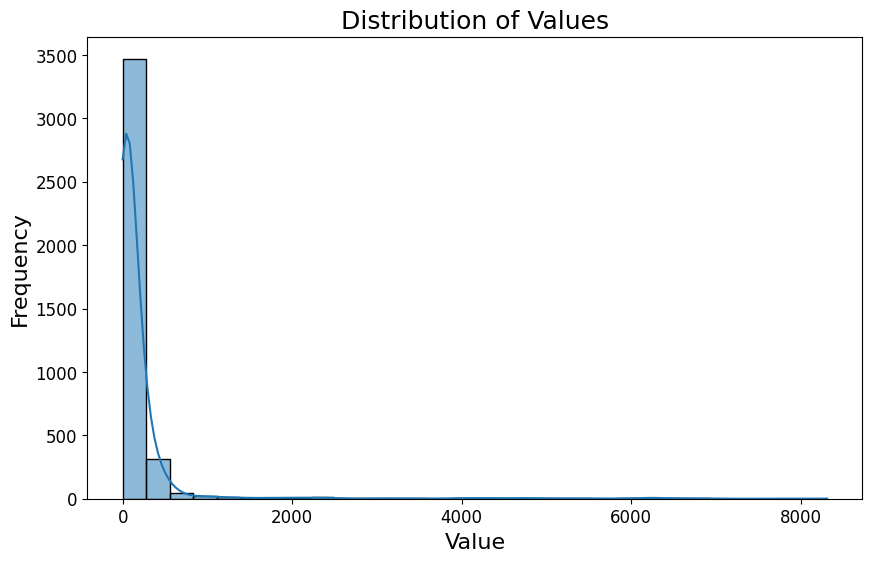

<Figure size 640x480 with 0 Axes>

In [212]:
# Visualise distributions of key variables
plt.figure(figsize=(10, 6))
sns.histplot(data['VALUE'], bins=30, kde=True)
plt.title('Distribution of Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()
# Save the plot
hist_path = os.path.join(outputs_dir, 'value_distribution.png')
plt.savefig(hist_path)

### All Ireland Value over the years

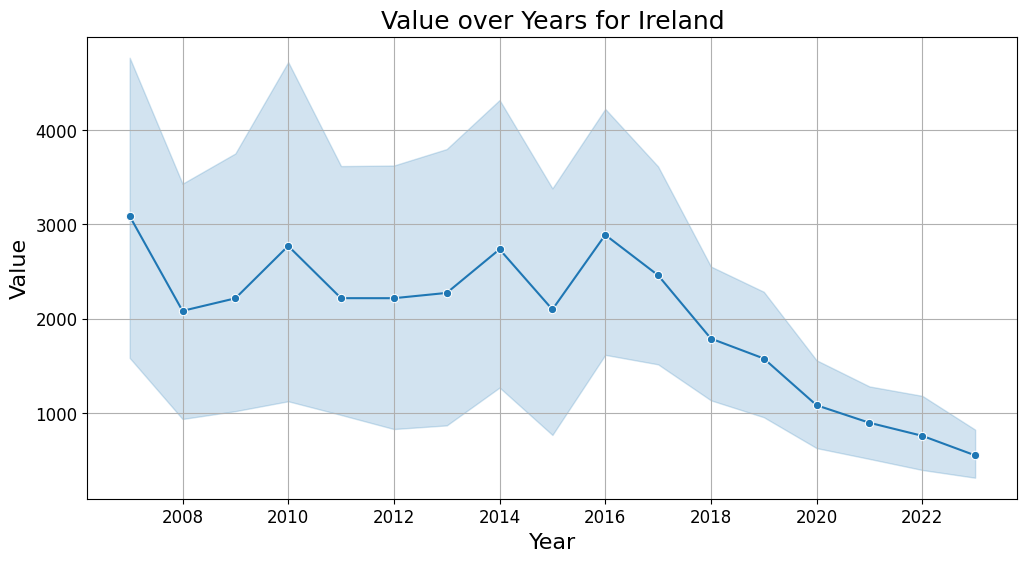

<Figure size 640x480 with 0 Axes>

In [213]:
# Visualise the Value over the years for Ireland as a whole
ireland_data = data[data['County'] == 'Ireland']
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='VALUE', data=ireland_data, marker='o')
plt.title('Value over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid()
plt.show()
# Save the plot
lineplot_path = os.path.join(outputs_dir, 'value_over_years_ireland.png')
plt.savefig(lineplot_path)

### Species Afforestation for Ireland as a whole

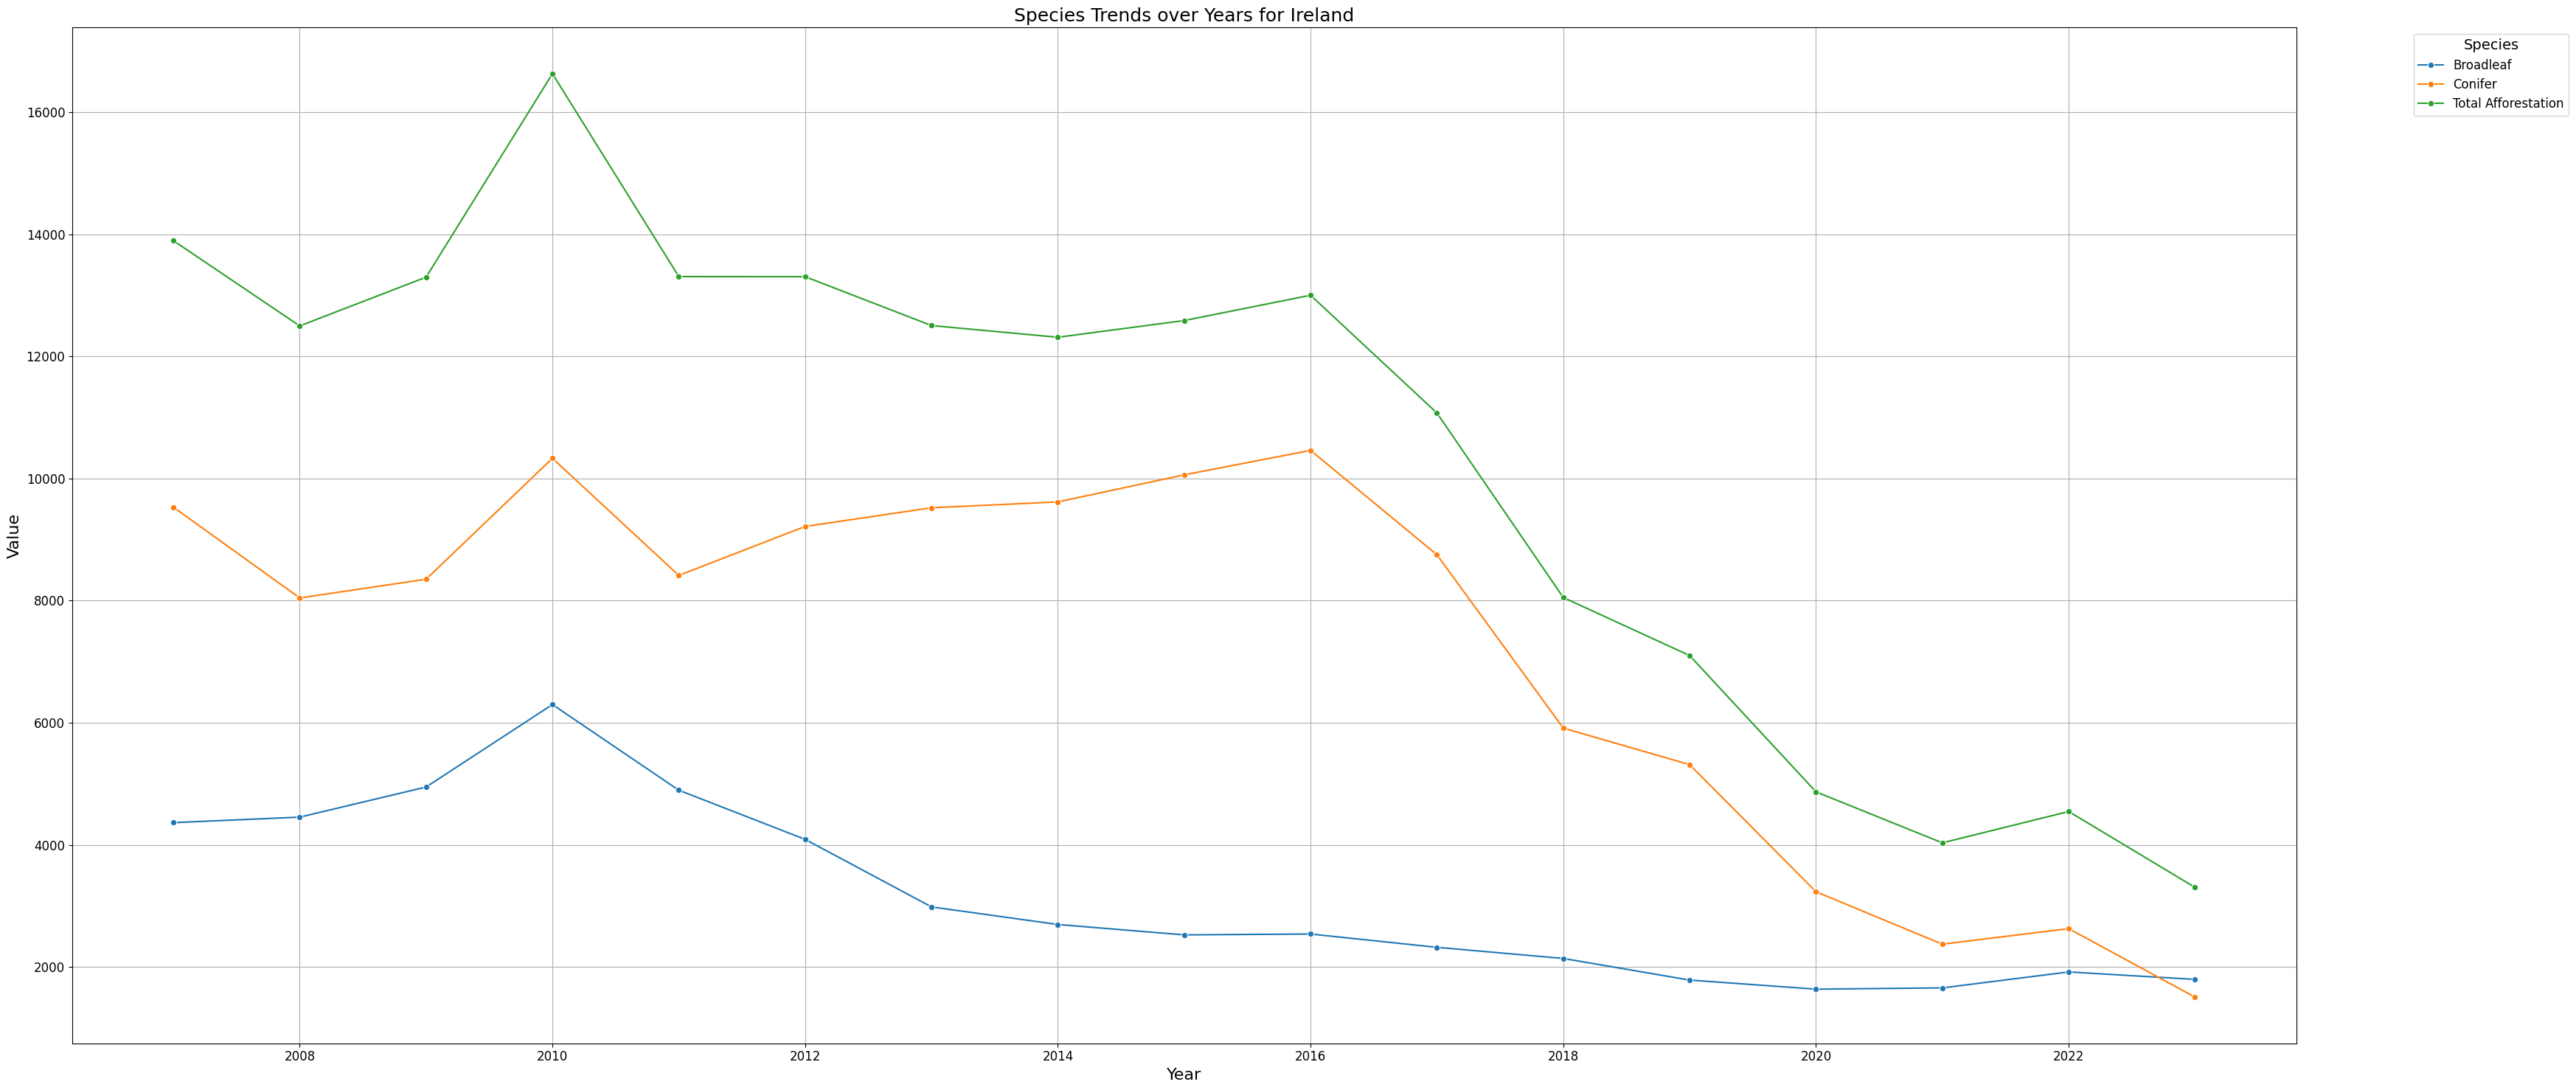

<Figure size 640x480 with 0 Axes>

In [214]:
# Analyse data over the years for Ireland as a whole. Look at species trends.
species_trends = ireland_data.groupby(['Year', 'Species'])['VALUE'].sum().reset_index()
plt.figure(figsize=(35, 15))
sns.lineplot(x='Year', y='VALUE', hue='Species', data=species_trends, marker='o')
plt.title('Species Trends over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
# Save the plot
species_trends_path = os.path.join(outputs_dir, 'species_trends_ireland.png')
plt.savefig(species_trends_path)    

### Correlation Matrix

                   Species_Code  Forest_Owner_Code     VALUE
Species_Code           1.000000           0.000500  0.123895
Forest_Owner_Code      0.000500           1.000000  0.055256
VALUE                  0.123895           0.055256  1.000000


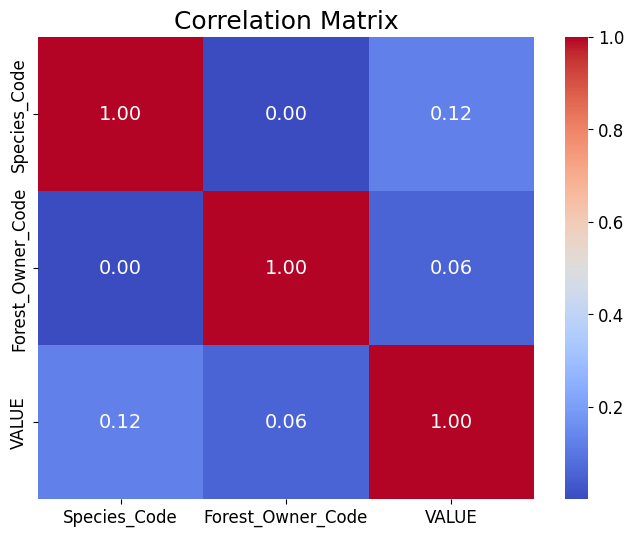

<Figure size 640x480 with 0 Axes>

In [215]:
# I wanted to look to see if there were any correlations between the species planted and the Forest owner.
correlation_data = data[['Species', 'Forest Owner', 'VALUE']]#
correlation_data = correlation_data.dropna()
correlation_data['Species_Code'] = correlation_data['Species'].astype('category').cat.codes
correlation_data['Forest_Owner_Code'] = correlation_data['Forest Owner'].astype('category').cat.codes
correlation_matrix = correlation_data[['Species_Code', 'Forest_Owner_Code', 'VALUE']].corr()
print(correlation_matrix)
# Visualize the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
# Save the plot
correlation_matrix_path = os.path.join(outputs_dir, 'correlation_matrix.png')
plt.savefig(correlation_matrix_path)    
# Save the correlation matrix to a CSV file
correlation_matrix_csv_path = os.path.join(outputs_dir, 'correlation_matrix.csv')
correlation_matrix.to_csv(correlation_matrix_csv_path)

The Correlation Matrix shows no correlation between the Species planted and the Forest Owner.

### Forest Owner over the Years

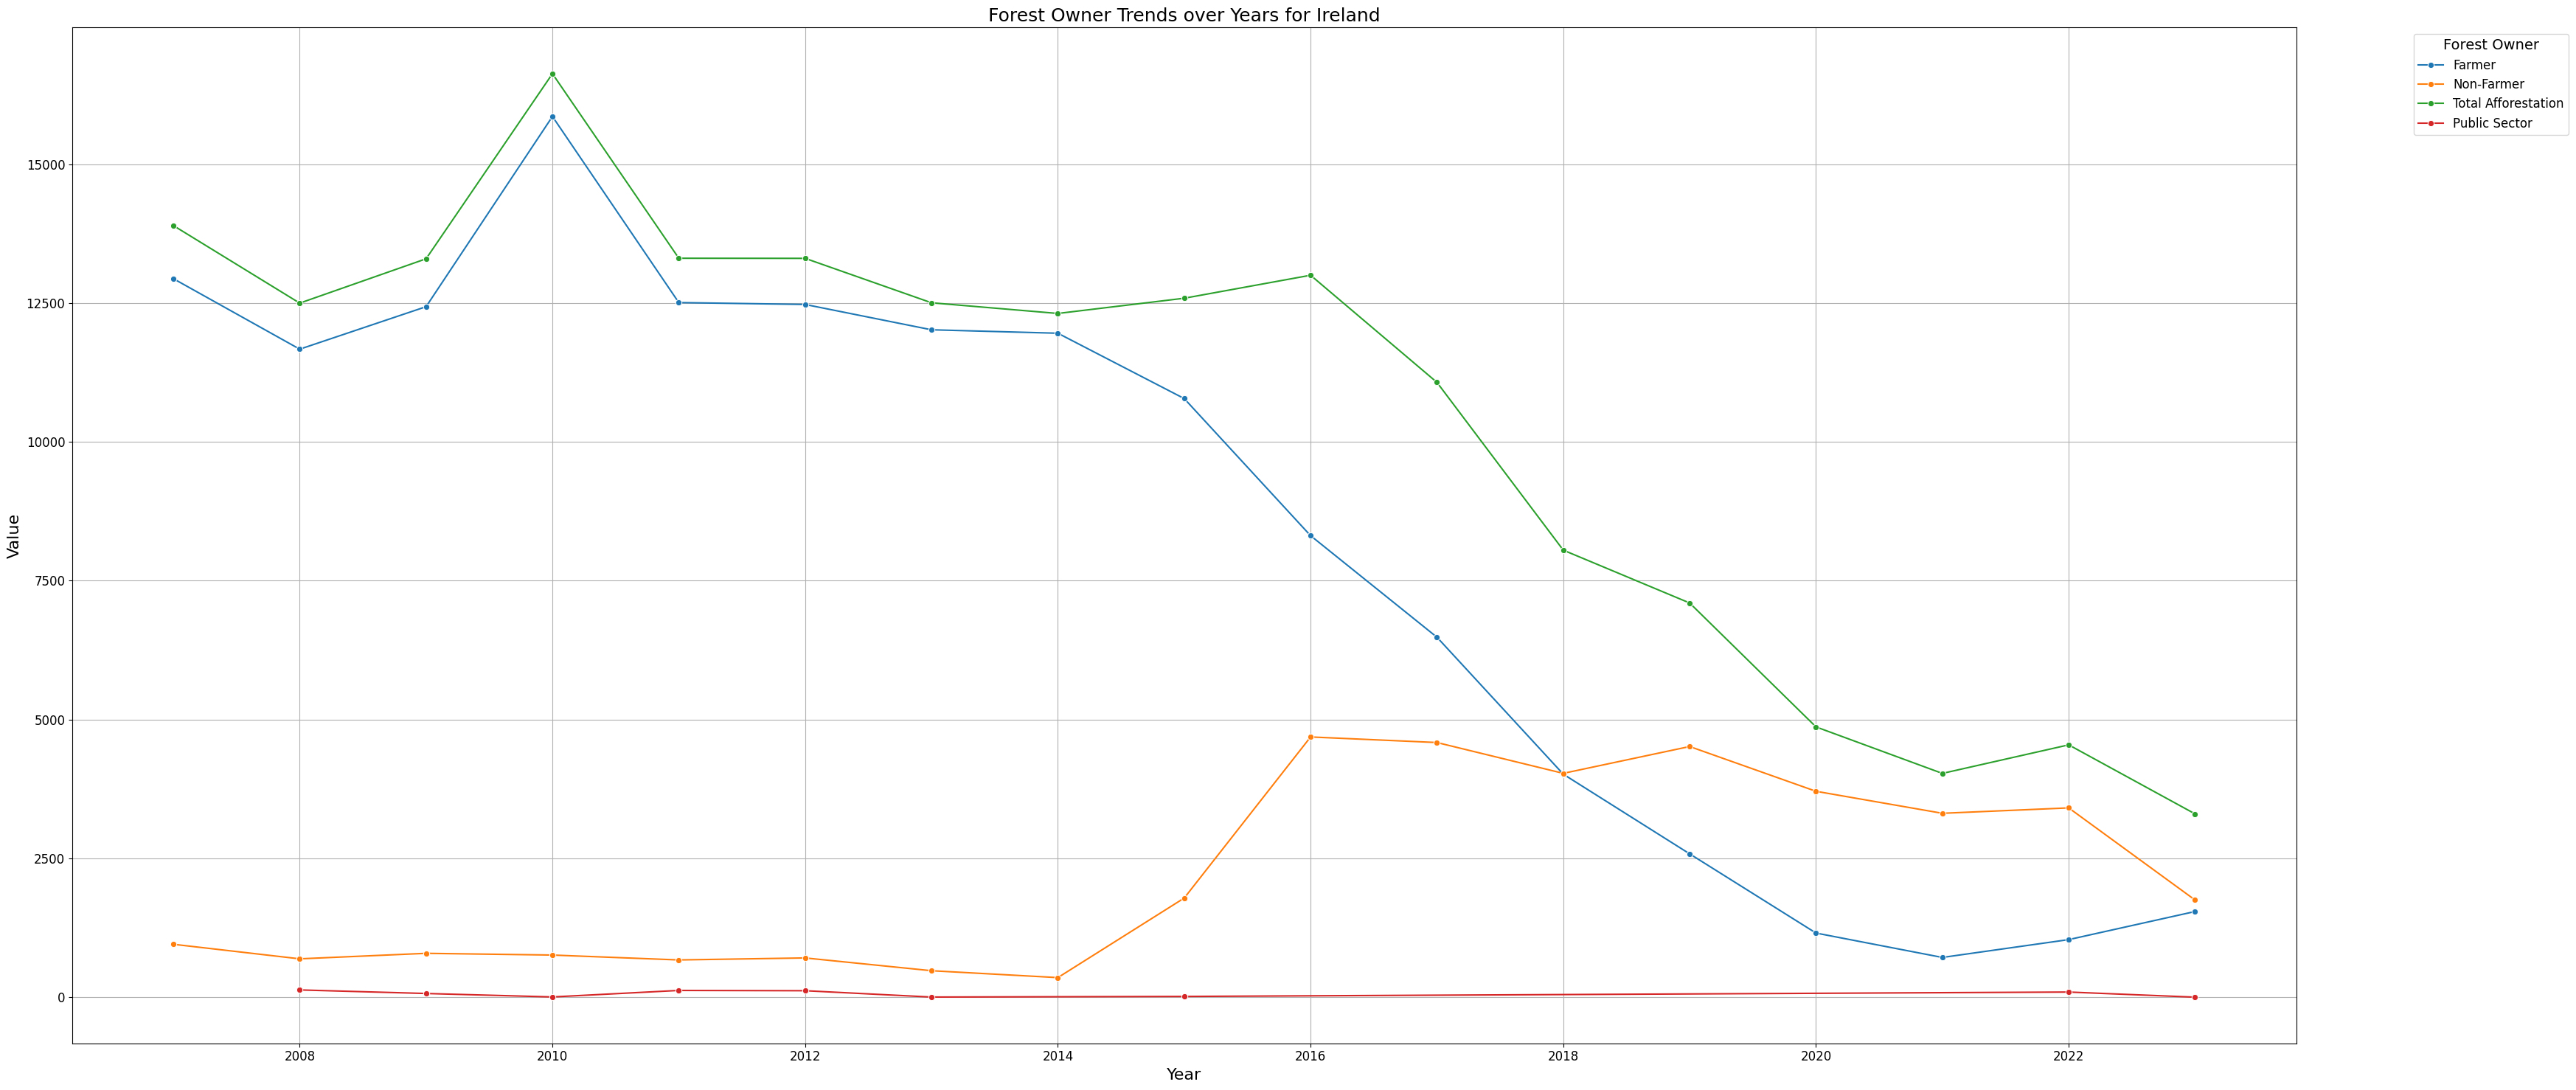

<Figure size 640x480 with 0 Axes>

In [216]:
# Now for analysis for the forest owner types over the years for Ireland as a whole
forest_owner_trends = ireland_data.groupby(['Year', 'Forest Owner'])['VALUE'].sum().reset_index()
plt.figure(figsize=(35, 15))
sns.lineplot(x='Year', y='VALUE', hue='Forest Owner', data=forest_owner_trends, marker='o')
plt.title('Forest Owner Trends over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Forest Owner', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
# Save the plot
forest_owner_trends_path = os.path.join(outputs_dir, 'forest_owner_trends_ireland.png')
plt.savefig(forest_owner_trends_path)

## Specific County Analysis

Breakdown the counties and remove Ireland as an option.

In [217]:
# Now I want to analyse the data for specific counties. I want to look at the top 5 counties with the highest total value over the years.
county_totals = data[data['County'] != 'Ireland'].groupby('County')['VALUE'].sum().reset_index()
top_5_counties = county_totals.nlargest(5, 'VALUE')['County'].tolist()
print("Top 5 Counties with highest total value over the years:", top_5_counties)

Top 5 Counties with highest total value over the years: ['Co. Cork', 'Co. Clare', 'Co. Kerry', 'Co. Mayo', 'Co. Roscommon']


For easier visual interpretation I decided to overlay the plots for the top 5 counties.

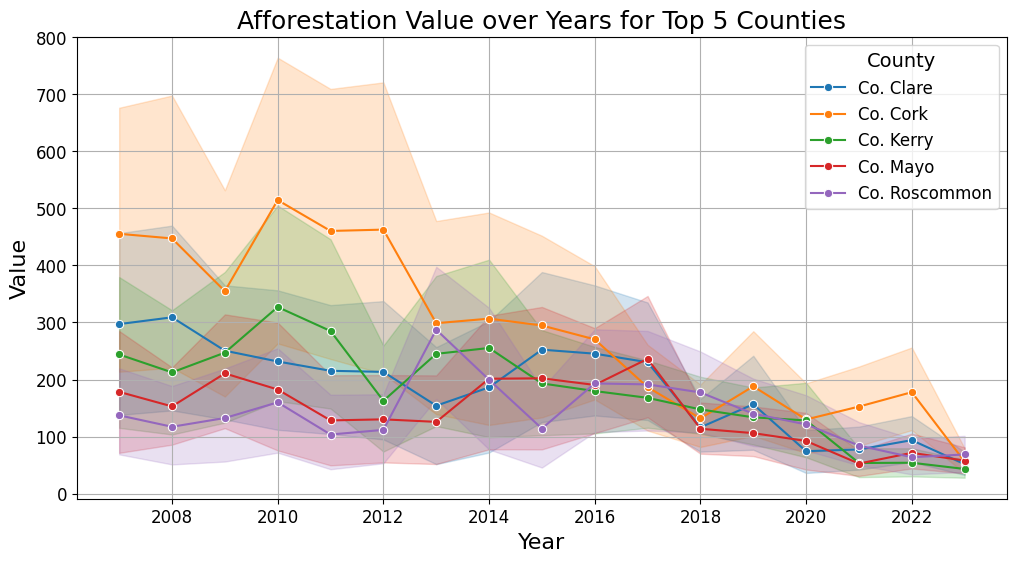

<Figure size 640x480 with 0 Axes>

In [218]:
# Overlay plots for value over years for top 5 counties
top_5_data = data[data['County'].isin(top_5_counties)]
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='VALUE', hue='County', data=top_5_data, marker='o')
plt.title('Afforestation Value over Years for Top 5 Counties')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid()
plt.show()
# Save the plot
overlay_plot_path = os.path.join(outputs_dir, 'value_over_years_top5_counties.png')
plt.savefig(overlay_plot_path)

I wanted to do multiple types of plots with the data to aid in visual interpretation.
For these plots each county was created and saved individually. The first is looking directly at the afforestation value for each year, the second is looking at the Species trends in the counties, whether Conifer or Broadleaf was planted. The third is looking at the Forest Owner trends in the county, Forest Owner was defined as Farmer, Non-Farmer, or Public Sector.

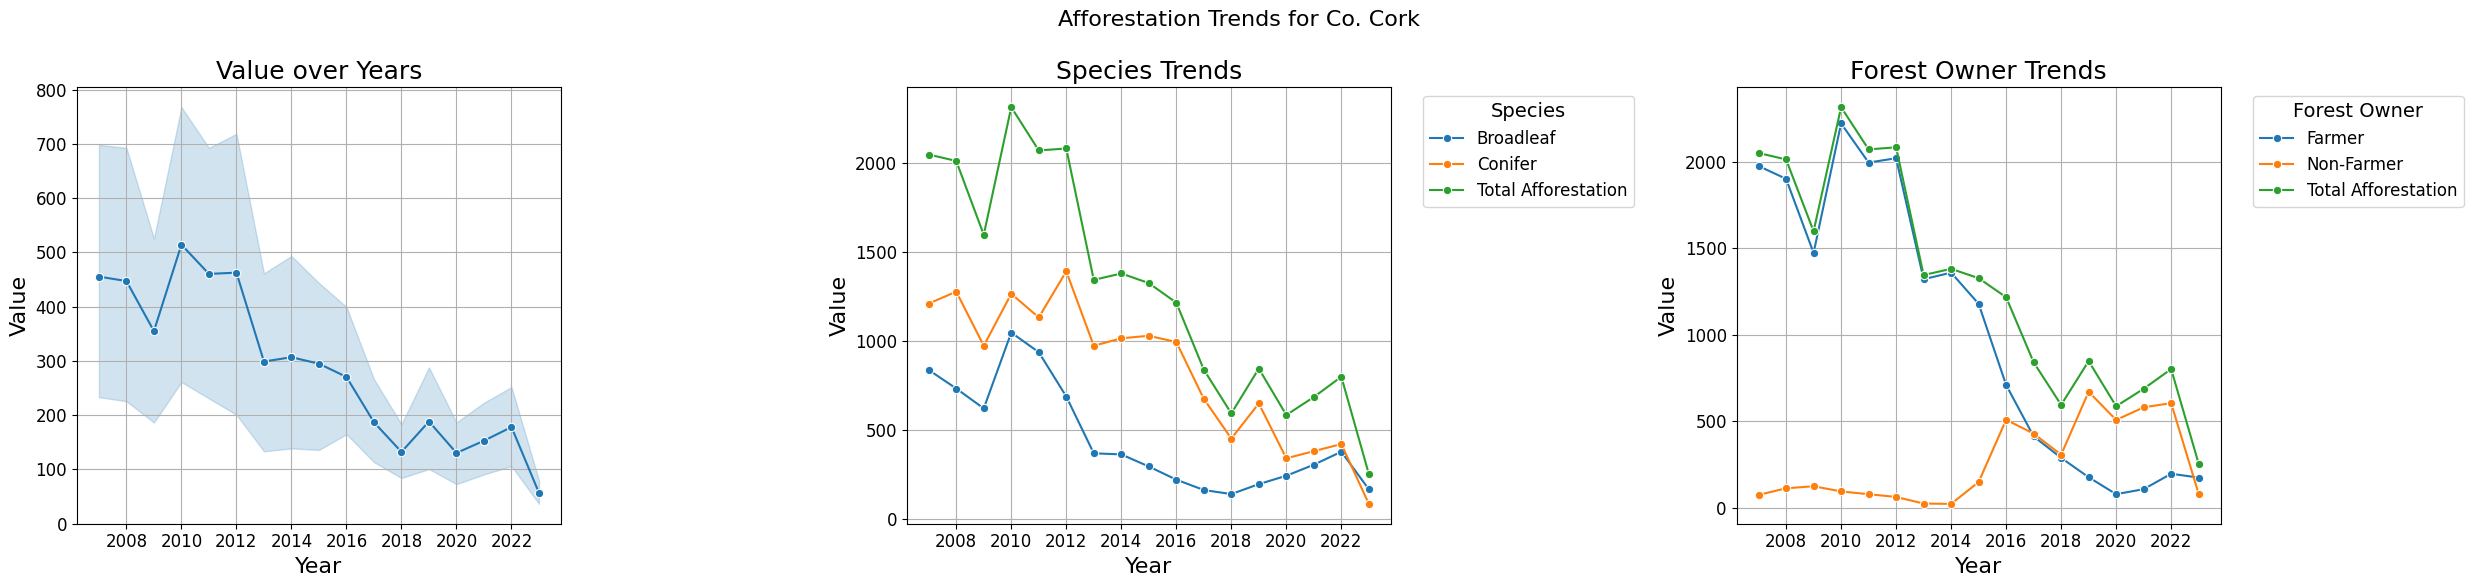

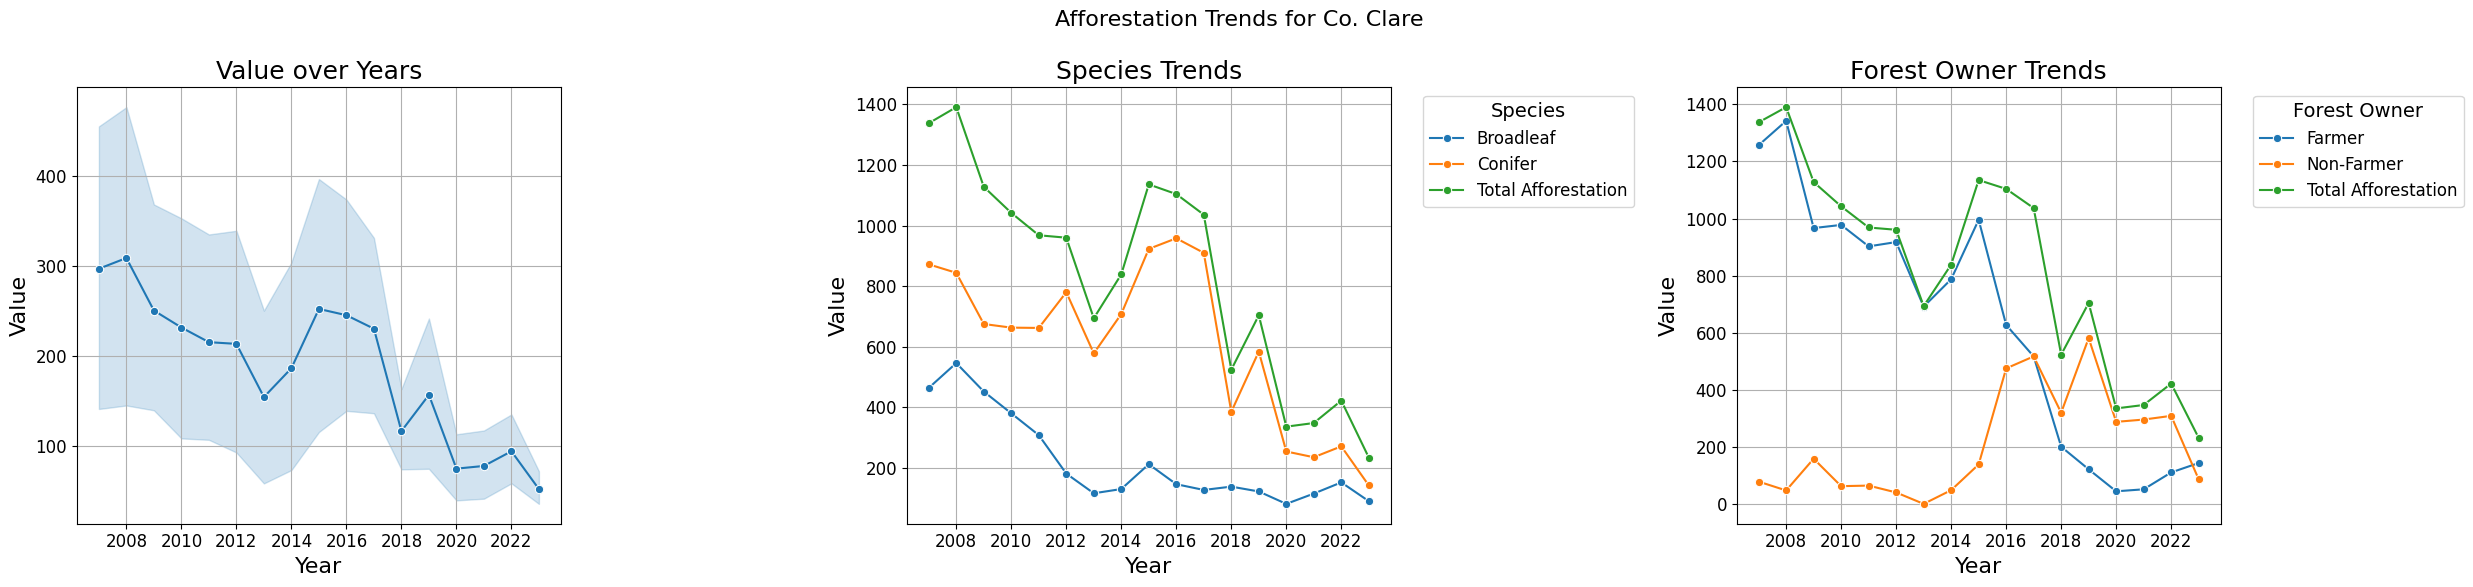

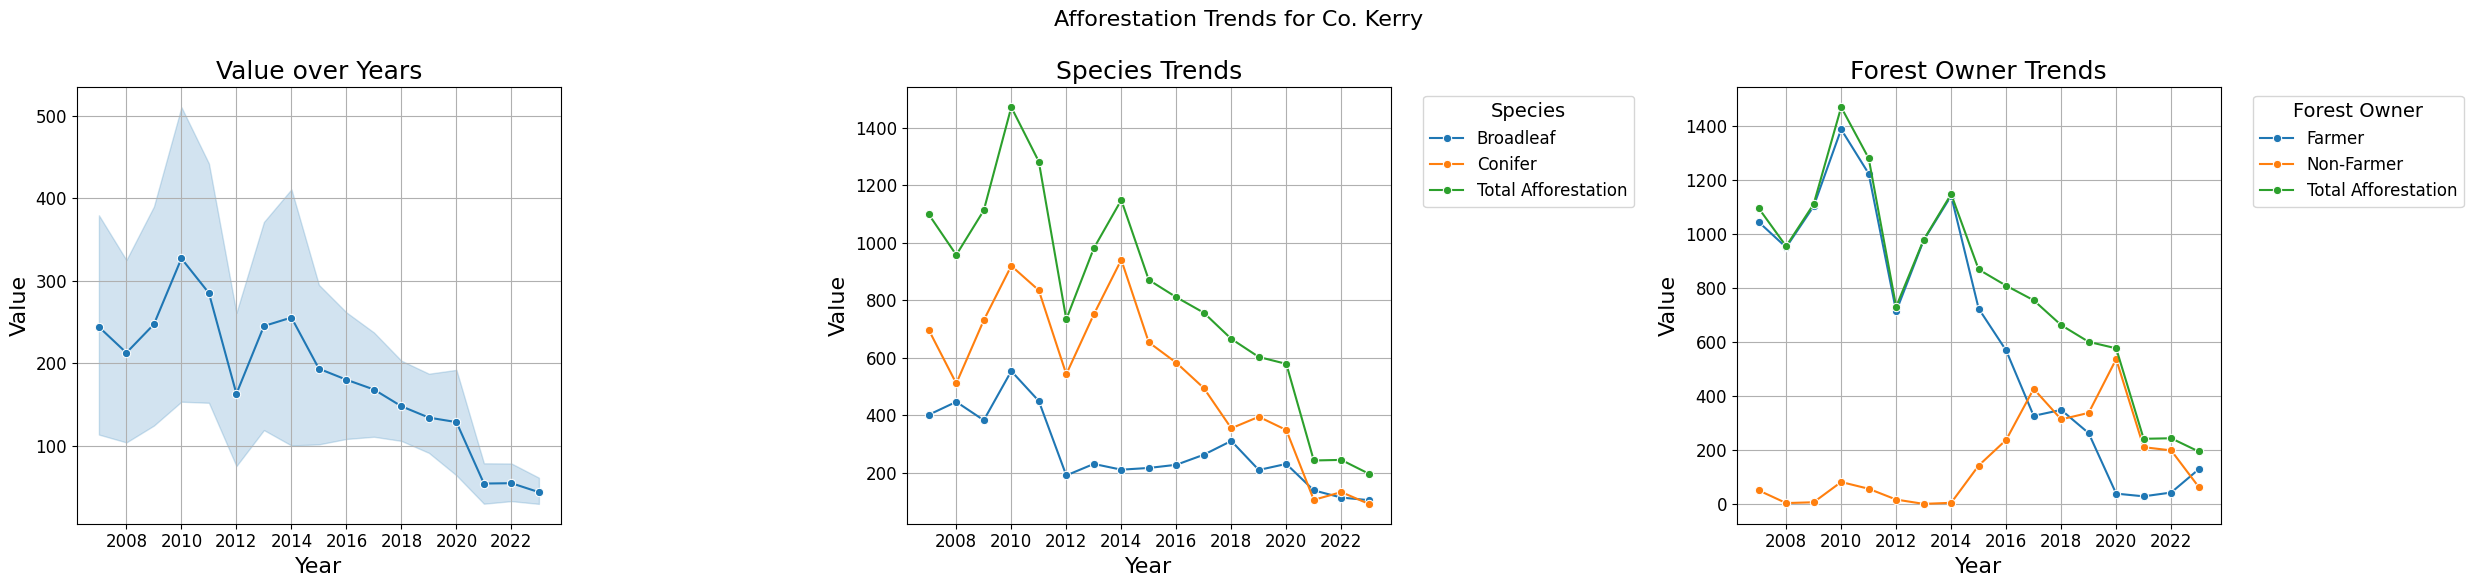

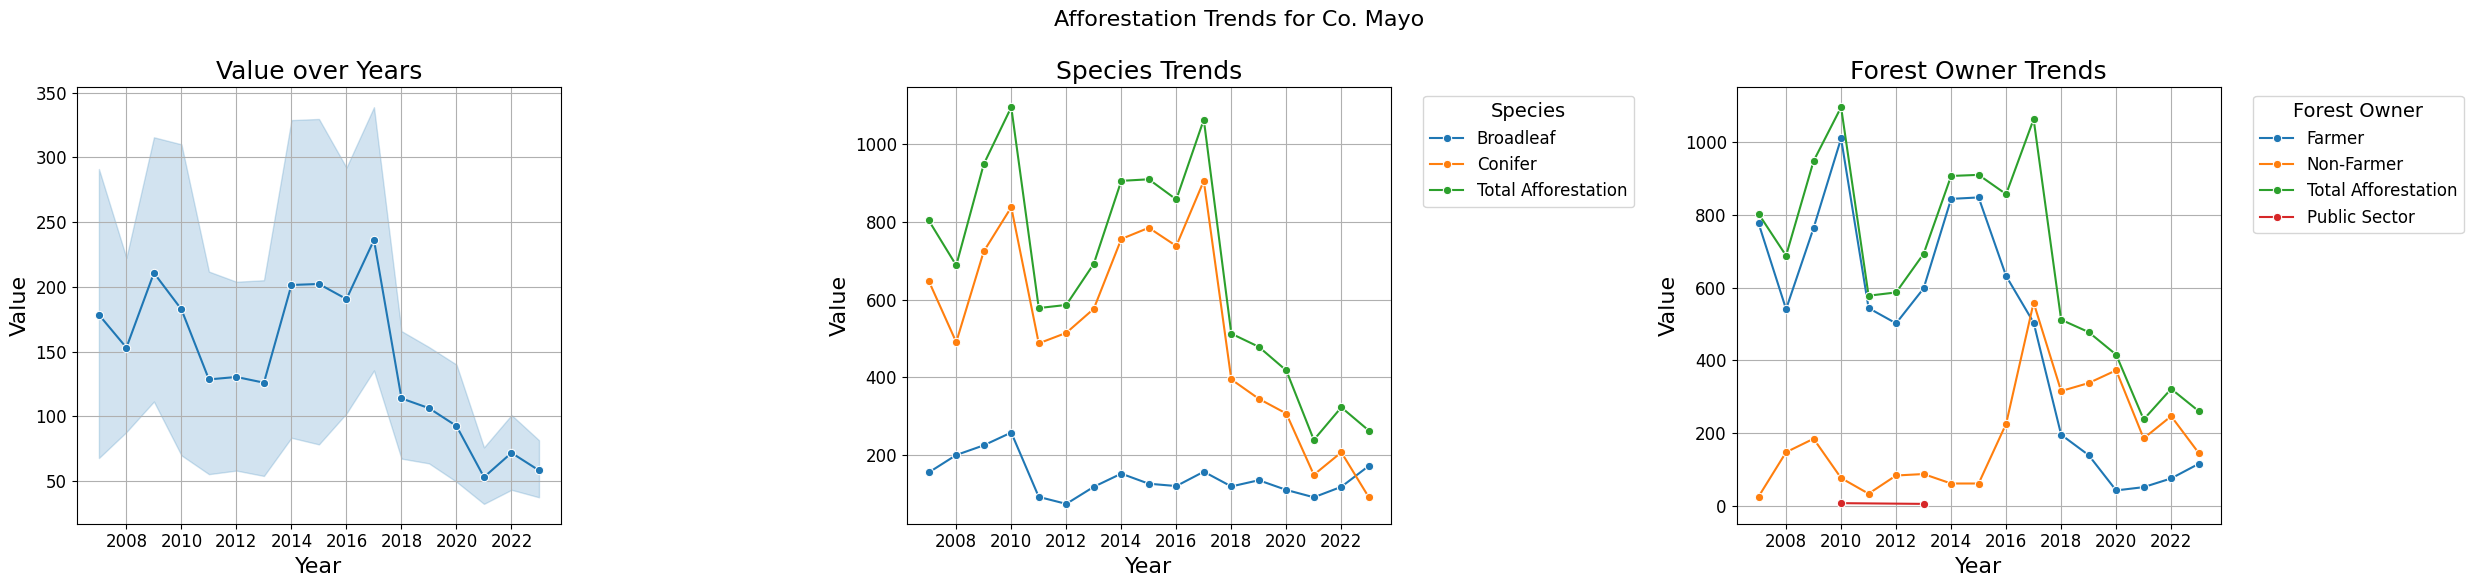

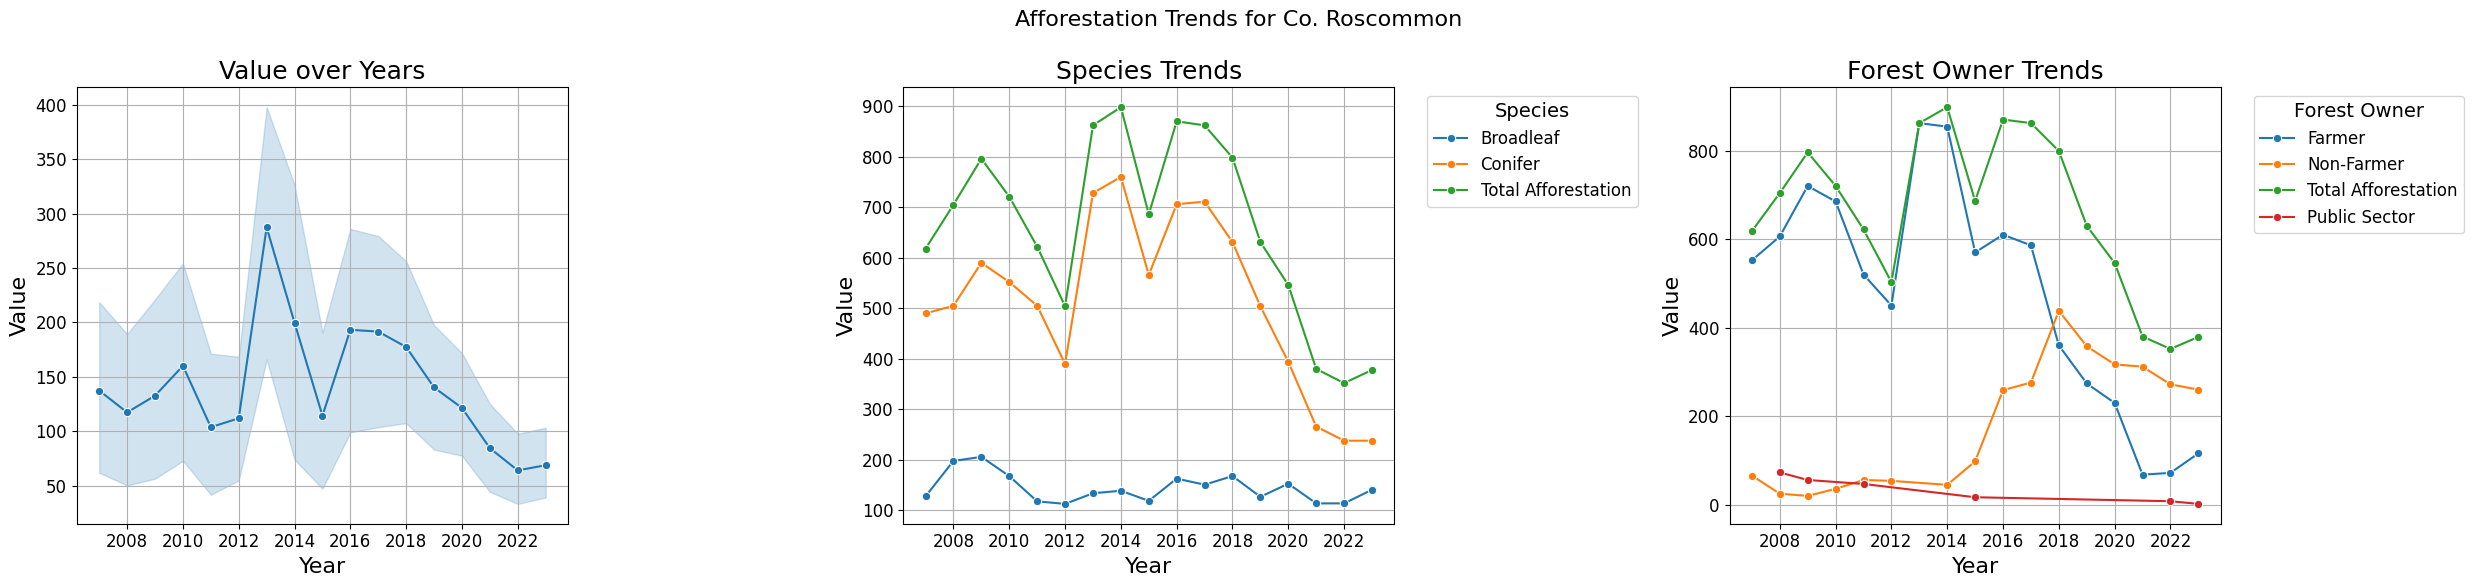

In [219]:
for county in top_5_counties:
    county_data = data[data['County'] == county]
    
    # Create a combined subplot for the county: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(25, 6))
    fig.suptitle(f'Afforestation Trends for {county}', fontsize=16)
    
    # Left subplot: Value over Years
    sns.lineplot(x='Year', y='VALUE', data=county_data, marker='o', ax=axes[0])
    axes[0].set_title('Value over Years')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Value')
    axes[0].grid()
    
    # Middle subplot: Species Trends
    species_trends_county = county_data.groupby(['Year', 'Species'])['VALUE'].sum().reset_index()
    sns.lineplot(x='Year', y='VALUE', hue='Species', data=species_trends_county, marker='o', ax=axes[1])
    axes[1].set_title('Species Trends')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Value')
    axes[1].legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid()
    
    # Right subplot: Forest Owner Trends
    forest_owner_trends_county = county_data.groupby(['Year', 'Forest Owner'])['VALUE'].sum().reset_index()
    sns.lineplot(x='Year', y='VALUE', hue='Forest Owner', data=forest_owner_trends_county, marker='o', ax=axes[2])
    axes[2].set_title('Forest Owner Trends')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('Value')
    axes[2].legend(title='Forest Owner', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[2].grid()
    
    plt.tight_layout()
    plt.show()
    # Save the combined plot for the county
    combined_county_path = os.path.join(outputs_dir, f'combined_{county.replace(" ", "_").lower()}.png')
    plt.savefig(combined_county_path)
    plt.close() # Got errors about memory use, so best to close the plots after saving.

As multiple plots can be difficult to refer between for visualising trends, I decided to create one plot with multiple sub-plots to give a better visualisation for the trends seen in the top 5 counties (Counties; Clare, Cork, Kerry, Mayo, and Roscommon). 

I used the basis from my [pands project](https://github.com/KaiiMenai/pands-project/blob/main/analysis.py) where I made multiple subplots as a basis for this. Further reference aid was made from [matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) and [seaborn](https://seaborn.pydata.org/tutorial/aesthetics.html#seaborn-figure-styles) to aid in readability.

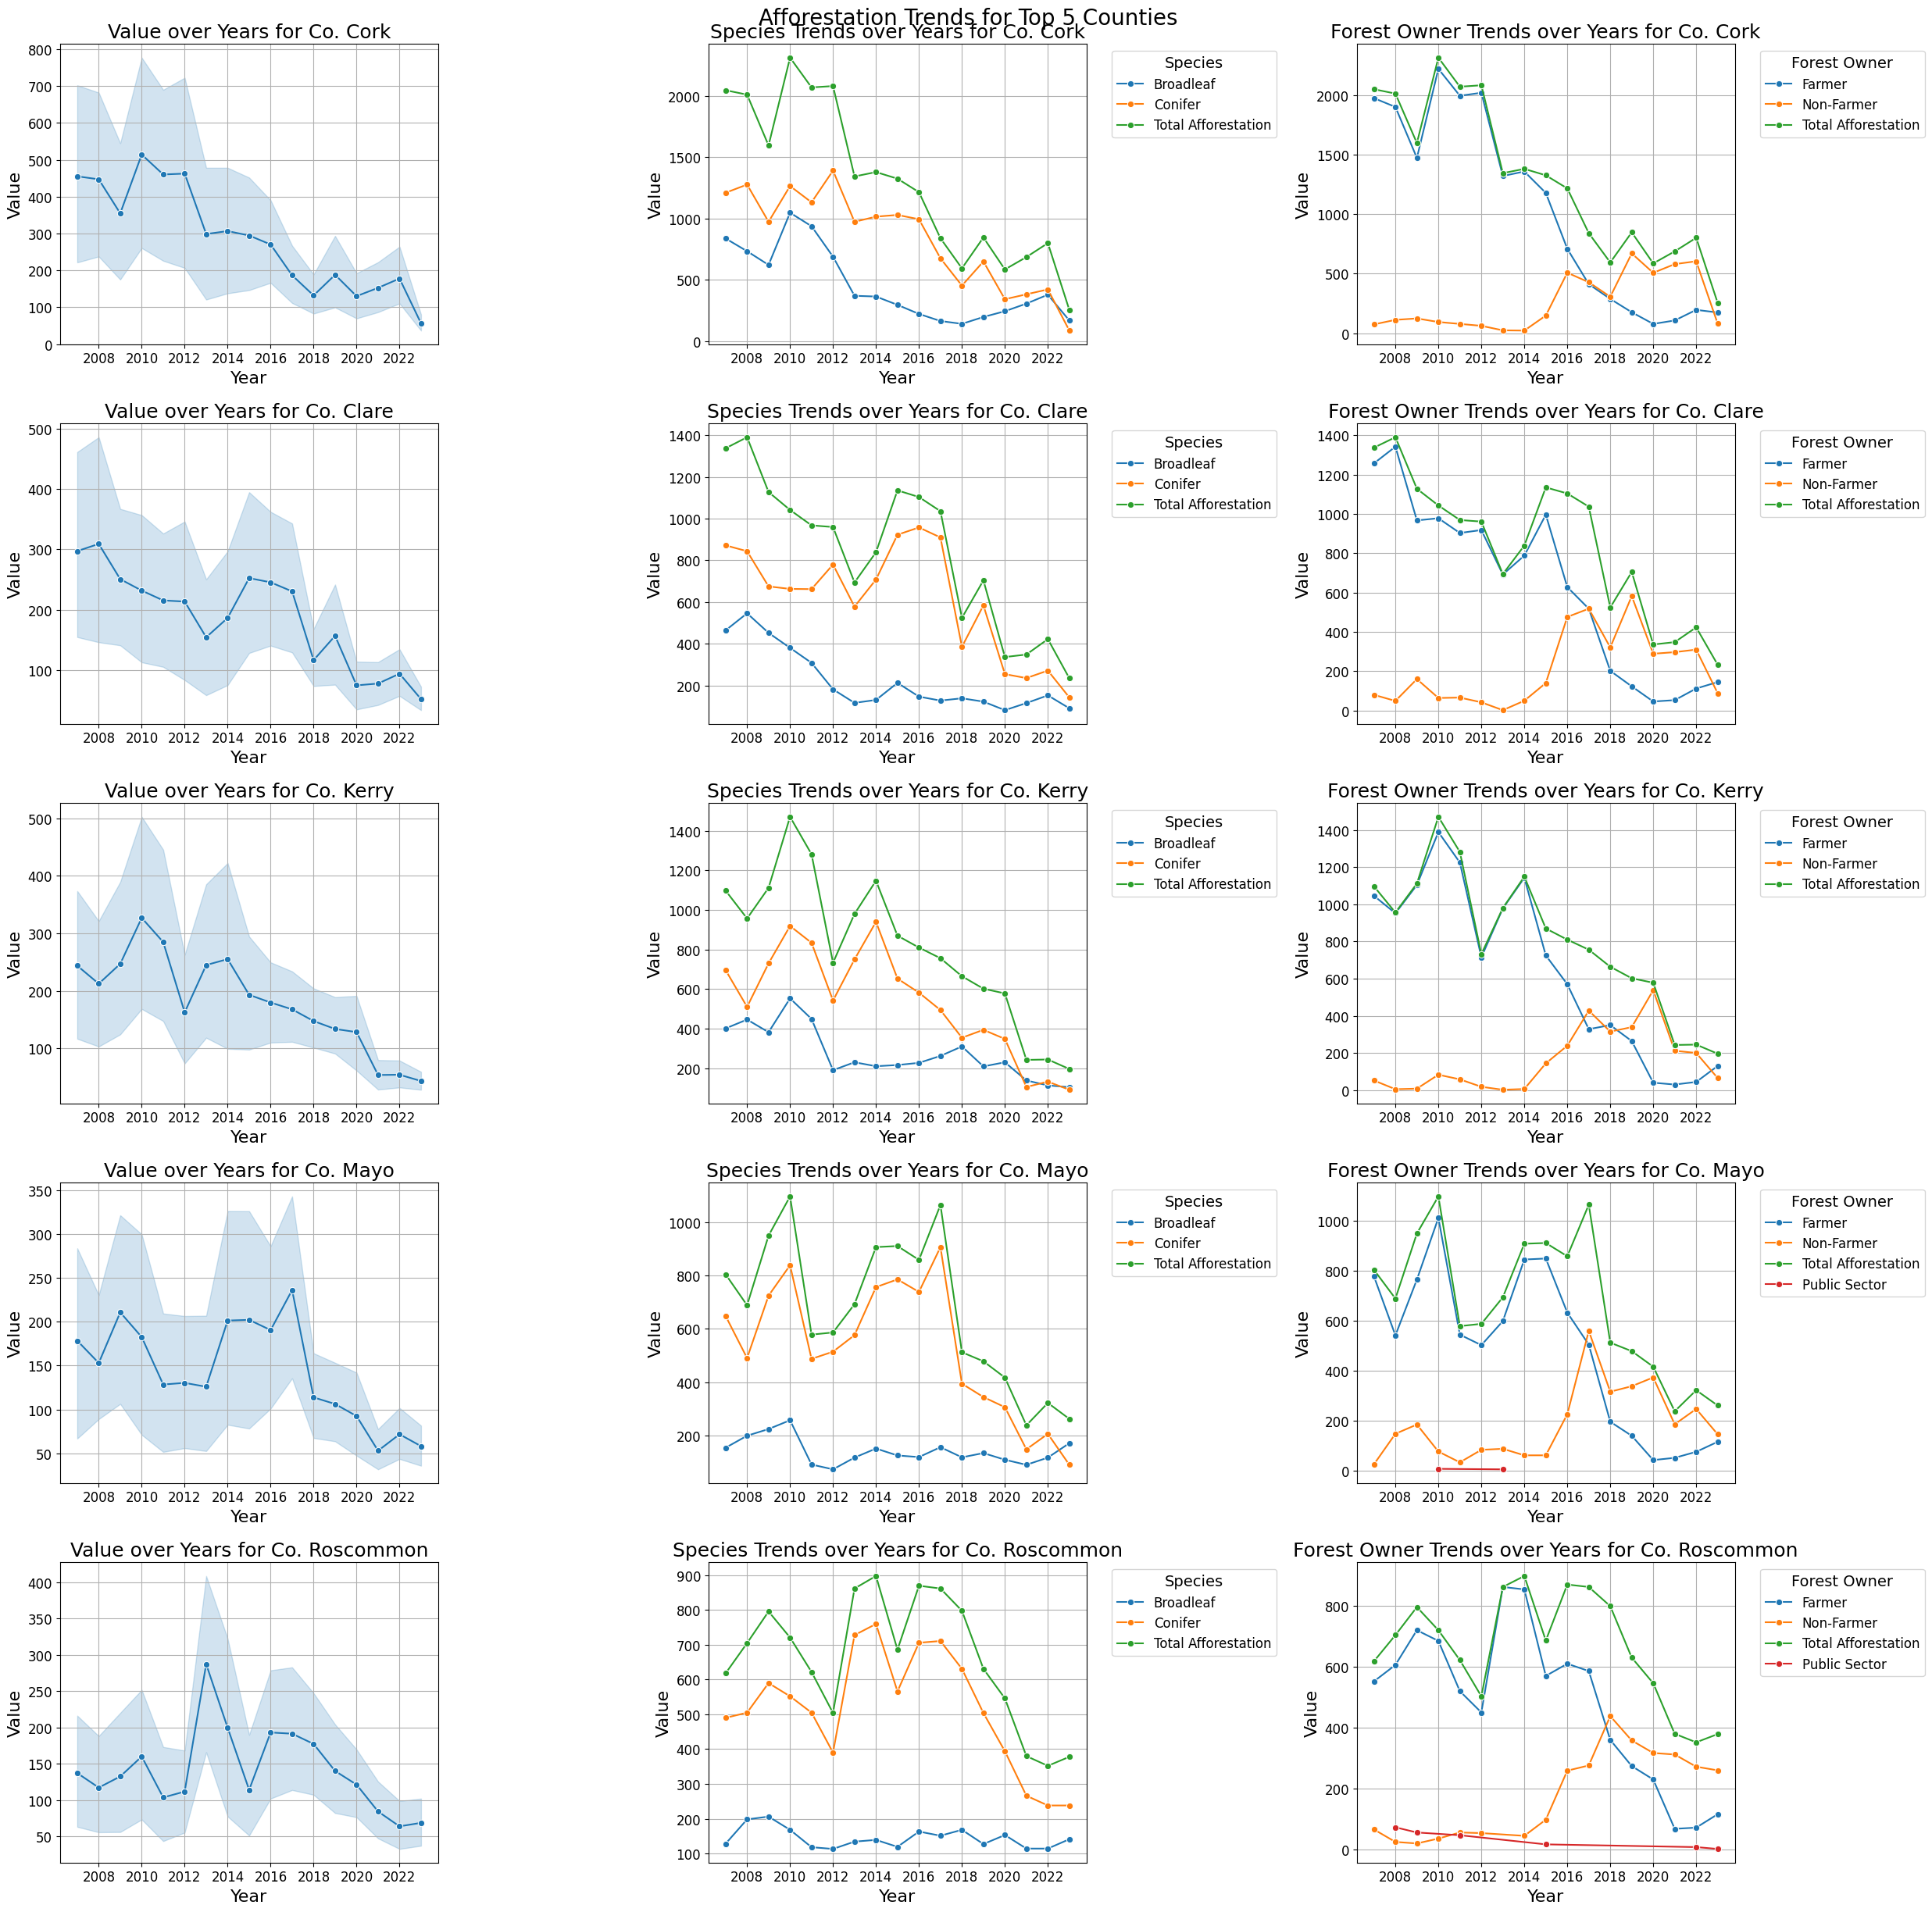

In [220]:
# Combined subplots for top 5 counties: value over years, species trends, and forest owner trends
fig, axes = plt.subplots(5, 3, figsize=(25, 25))
fig.suptitle('Afforestation Trends for Top 5 Counties', fontsize=20)

for i, county in enumerate(top_5_counties):
    county_data = data[data['County'] == county]
    
    # Left subplot: Value over Years
    ax1 = axes[i, 0]
    sns.lineplot(x='Year', y='VALUE', data=county_data, marker='o', ax=ax1)
    ax1.set_title(f'Value over Years for {county}')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Value')
    ax1.grid()
    
    # Middle subplot: Species Trends
    ax2 = axes[i, 1]
    species_trends_county = county_data.groupby(['Year', 'Species'])['VALUE'].sum().reset_index()
    sns.lineplot(x='Year', y='VALUE', hue='Species', data=species_trends_county, marker='o', ax=ax2)
    ax2.set_title(f'Species Trends over Years for {county}')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Value')
    ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid()
    
    # Right subplot: Forest Owner Trends
    ax3 = axes[i, 2]
    forest_owner_trends_county = county_data.groupby(['Year', 'Forest Owner'])['VALUE'].sum().reset_index()
    sns.lineplot(x='Year', y='VALUE', hue='Forest Owner', data=forest_owner_trends_county, marker='o', ax=ax3)
    ax3.set_title(f'Forest Owner Trends over Years for {county}')
    ax3.set_xlabel('Year')
    ax3.set_ylabel('Value')
    ax3.legend(title='Forest Owner', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid()

plt.tight_layout()
plt.show()
# Save the combined plot
combined_plot_path = os.path.join(outputs_dir, 'combined_trends_top5_counties.png')
plt.savefig(combined_plot_path)
plt.close('all')  # I kept getting alerts for memory use so I added this as it tells py to close all figures to free memory


#### How I Created the Combined Subplots:

1. **Set up the figure and axes**: Used `plt.subplots(5, 3, figsize=(25, 25))` to create a 5 x 3 grid (5 counties, 3 plot types each).
2. **Added a main title**: `fig.suptitle('Afforestation Trends for Top 5 Counties', fontsize=20)` for the overall figure.
3. **Looped through counties**: For each of the top 5 counties, filtered the data and created three subplots per row.
4. **Left subplot (Value over Years)**: Simple line plot of VALUE vs Year for the county.
5. **Middle subplot (Species Trends)**: Grouped data by Year and Species, then plotted VALUE vs Year with Species as hue.
6. **Right subplot (Forest Owner Trends)**: Grouped data by Year and Forest Owner, then plotted VALUE vs Year with Forest Owner as hue.
7. **Customized each subplot**: Added titles, labels, grids, and legends (positioned outside to avoid overlap).
8. **Adjusted layout**: `plt.tight_layout()` to prevent overlapping, then saved with `plt.savefig()`.
9. **Closed figures**: Added `plt.close('all')` to free memory after saving.

This approach makes it easy to compare trends across counties and variables in one view.

### Plot for all counties - exclude Ireland

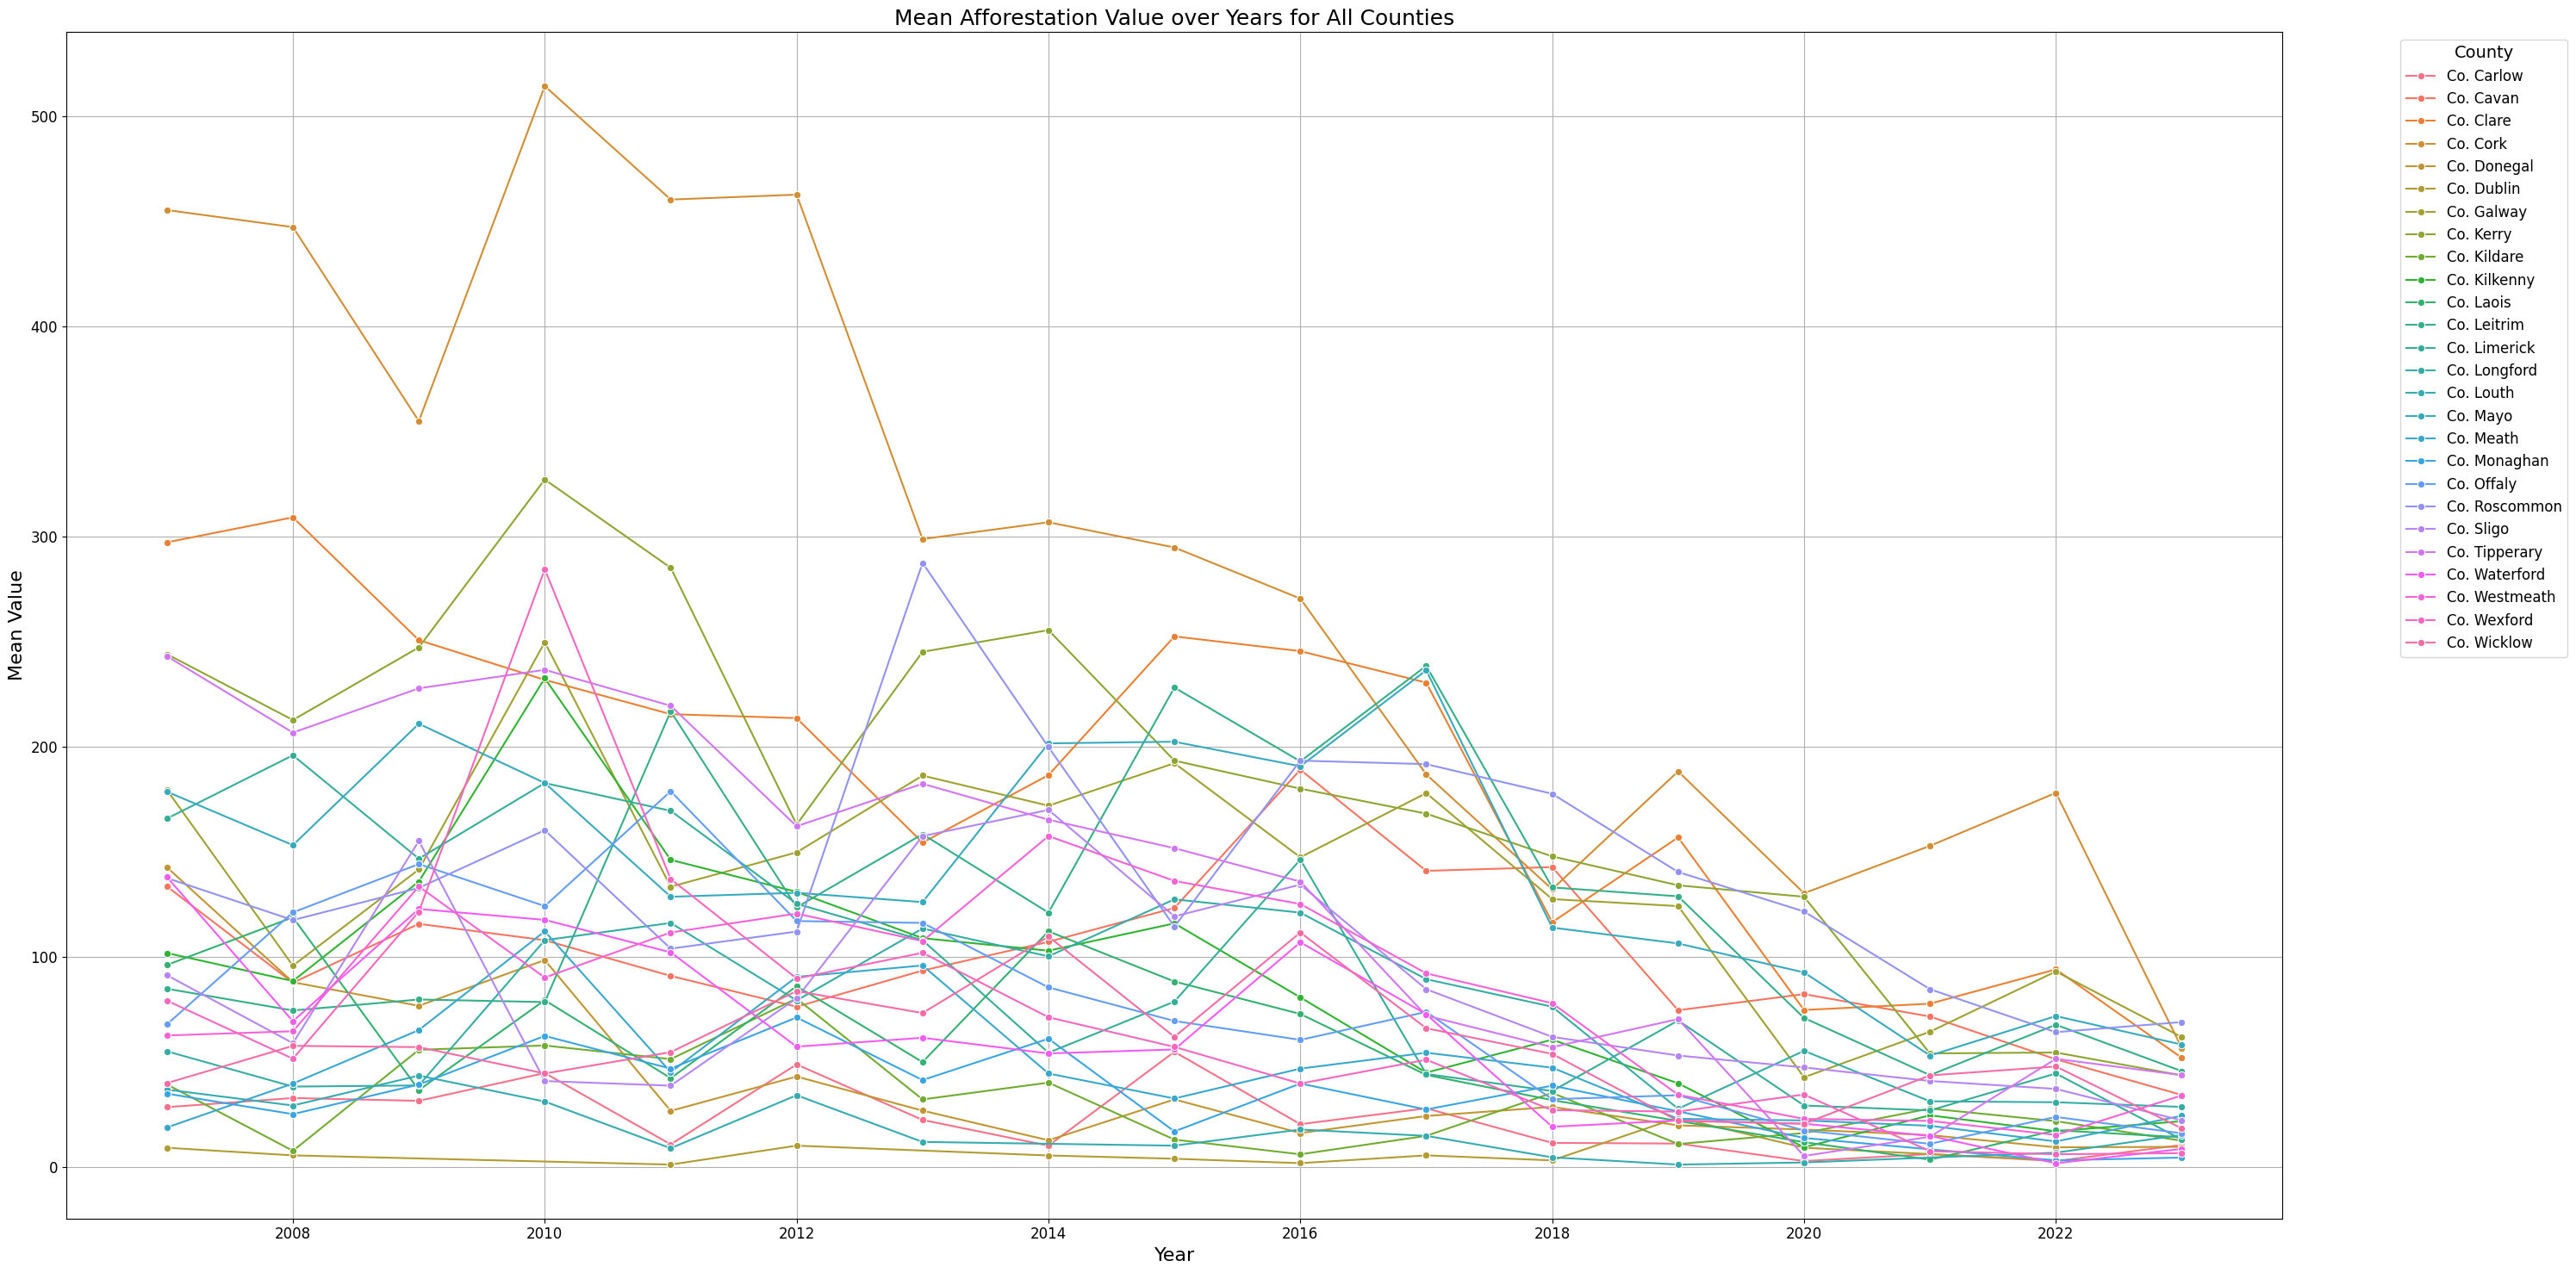

<Figure size 640x480 with 0 Axes>

In [221]:
# Plot mean VALUE over years for all counties (excluding Ireland)
counties_data = data[data['County'] != 'Ireland']
mean_value_per_year_county = counties_data.groupby(['Year', 'County'])['VALUE'].mean().reset_index()
plt.figure(figsize=(30, 15))
sns.lineplot(x='Year', y='VALUE', hue='County', data=mean_value_per_year_county, marker='o')
plt.title('Mean Afforestation Value over Years for All Counties')
plt.xlabel('Year')
plt.ylabel('Mean Value')
plt.legend(title='County', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
# Save the plot
all_counties_plot_path = os.path.join(outputs_dir, 'mean_value_over_years_all_counties.png')
plt.savefig(all_counties_plot_path)

### Afforestation over the years in Ireland

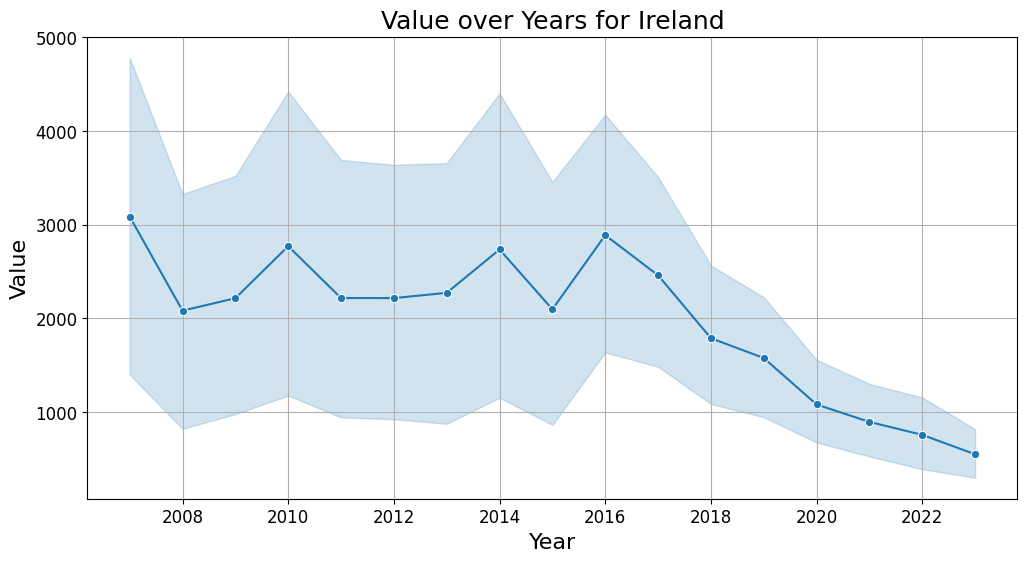

<Figure size 640x480 with 0 Axes>

In [222]:
# Visualise the Value over the years for Ireland as a whole
ireland_data = data[data['County'] == 'Ireland']
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='VALUE', data=ireland_data, marker='o')
plt.title('Value over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid()
plt.show()
# Save the plot
lineplot_path = os.path.join(outputs_dir, 'value_over_years_ireland.png')
plt.savefig(lineplot_path)

## Further Analysis

In [223]:
# I want to look to see if there has been a significant difference in afforestation between the first year and most recent year.
first_year = data['Year'].min()
most_recent_year = data['Year'].max()   
first_year_data = data[data['Year'] == first_year]['VALUE']
most_recent_year_data = data[data['Year'] == most_recent_year]['VALUE']
t_stat, p_value = stats.ttest_ind(first_year_data, most_recent_year_data)
print(f"T-statistic: {t_stat}, P-value: {p_value}")
if p_value < 0.05:
    print("There is a significant difference in afforestation between the first year and the most recent year.")
else:
    print("There is no significant difference in afforestation between the first year and the most recent year.")

T-statistic: 3.6131142322790937, P-value: 0.00033551932028967656
There is a significant difference in afforestation between the first year and the most recent year.


Plot to visualise the difference

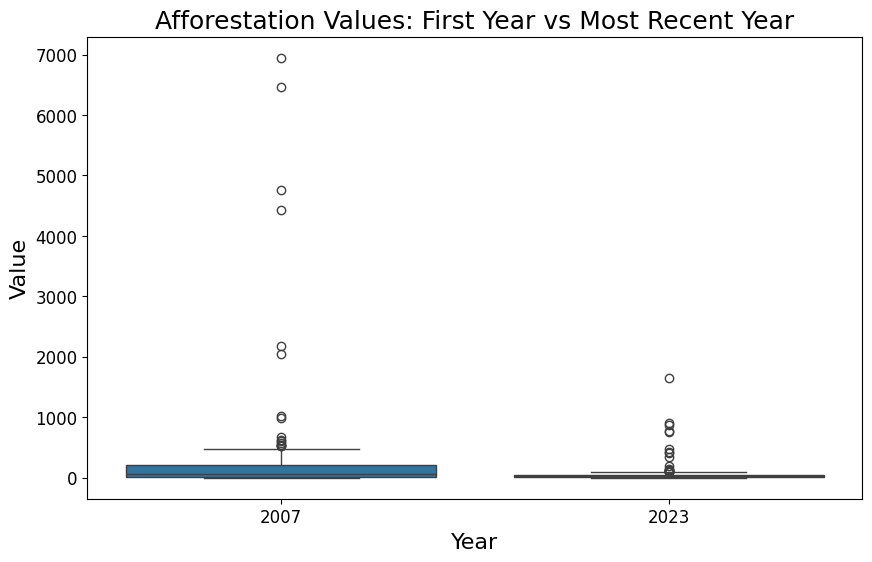

<Figure size 640x480 with 0 Axes>

In [224]:
# Since there is a difference in the afforestation between the first and most recent year, I want to visualise this using boxplots.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Year', y='VALUE', data=data[data['Year'].isin([first_year, most_recent_year])])
plt.title('Afforestation Values: First Year vs Most Recent Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.show()
# Save the plot
boxplot_path = os.path.join(outputs_dir, 'afforestation_boxplot.png')
plt.savefig(boxplot_path)

After seeing that there were differences in the afforestation between the first year recorded and the most recent recorded year, I wanted to see if there were any trends in the species being planted and the forest owner.

In [225]:
# Visualise forest owner trends vs species trends for Ireland.
ireland_data = data[data['County'] == 'Ireland']
forest_owner_trends_ireland = ireland_data.groupby(['Year', 'Forest Owner'])['VALUE'].sum().reset_index()
species_trends_ireland = ireland_data.groupby(['Year', 'Species'])['VALUE'].sum().reset_index()

First to look at Owner

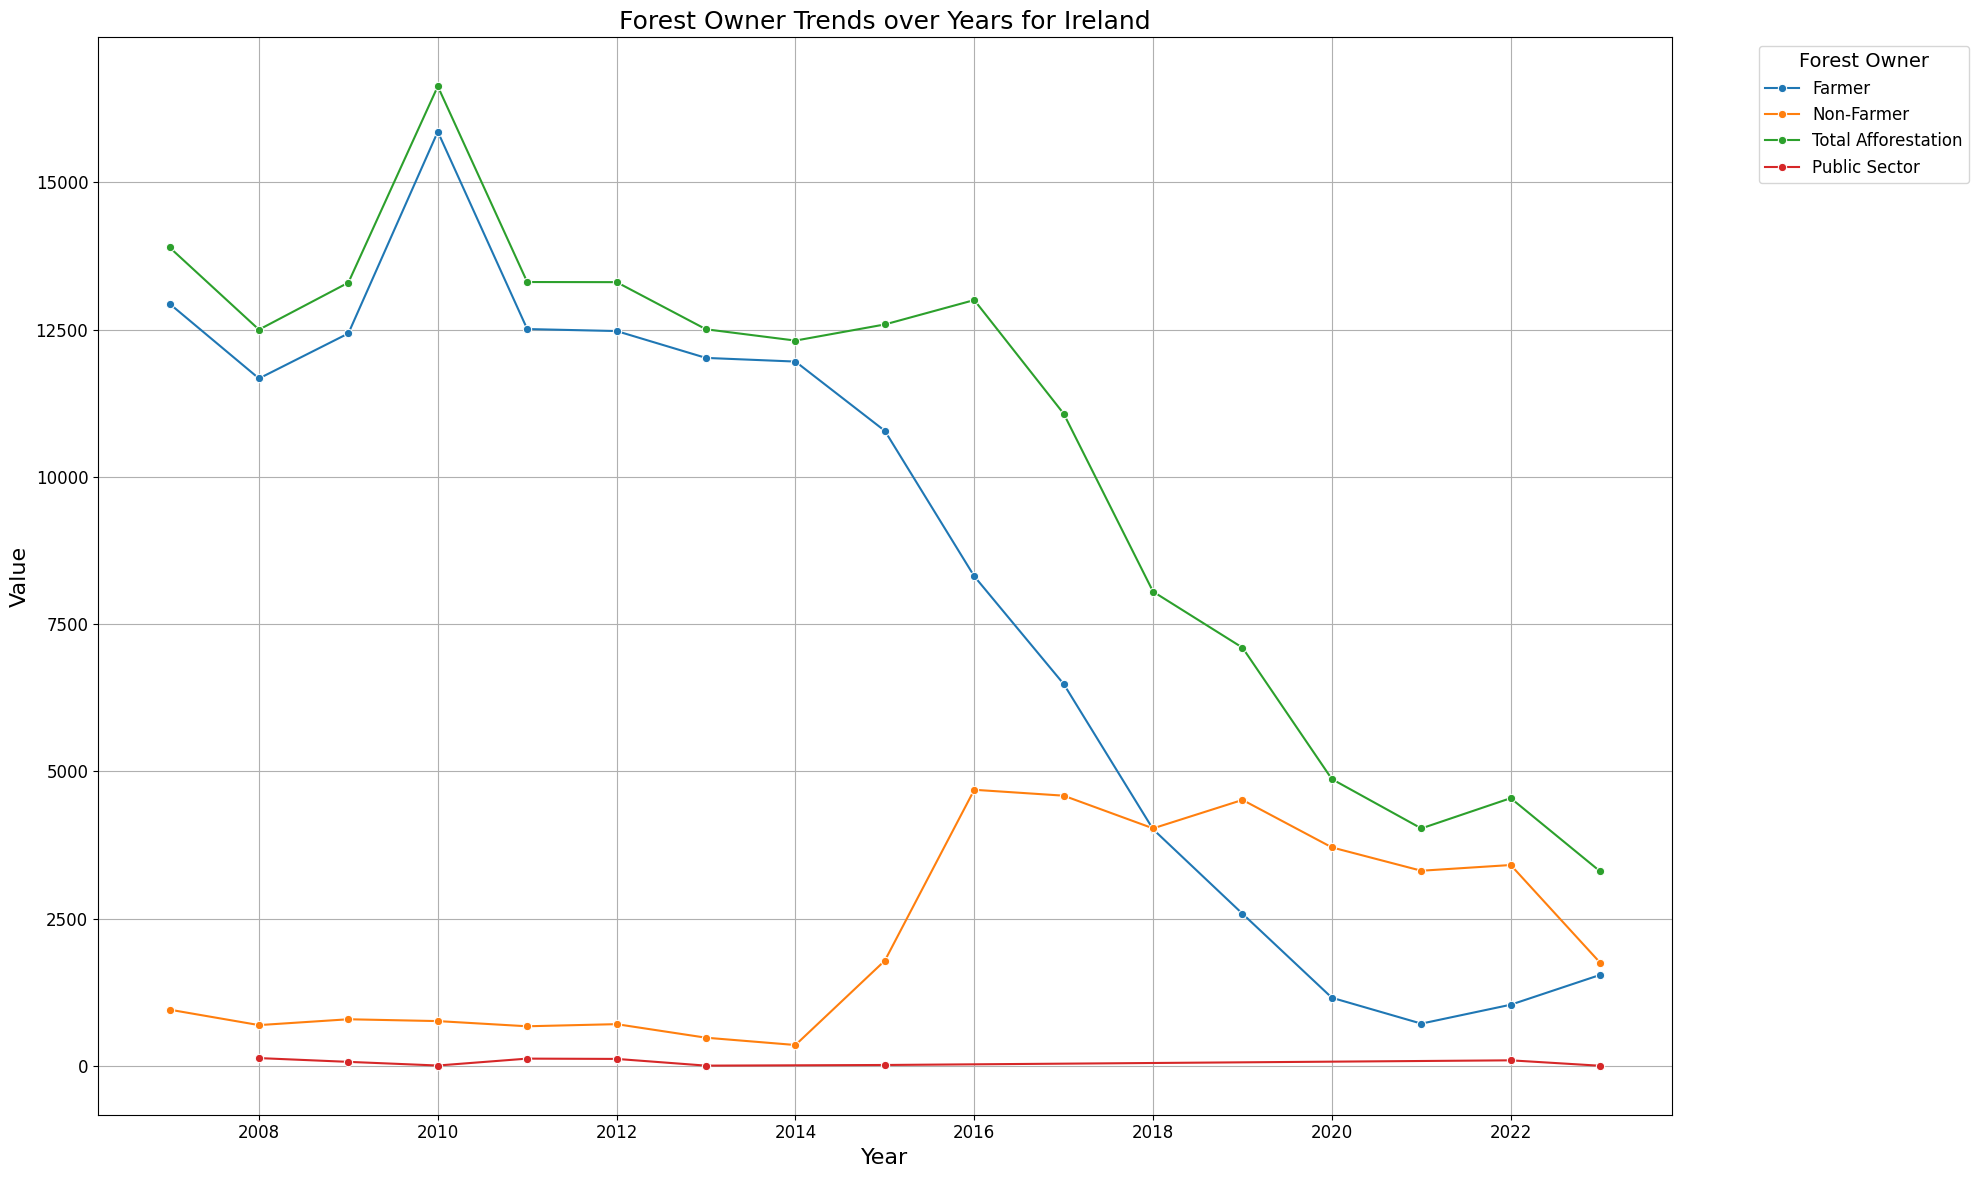

<Figure size 640x480 with 0 Axes>

In [226]:
plt.figure(figsize=(20, 12))
sns.lineplot(x='Year', y='VALUE', hue='Forest Owner', data=forest_owner_trends_ireland, marker='o')
plt.title('Forest Owner Trends over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Forest Owner', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
# Save the plot
forest_owner_trends_ireland_path = os.path.join(outputs_dir, 'forest_owner_trends_ireland.png')
plt.savefig(forest_owner_trends_ireland_path)

Then Species

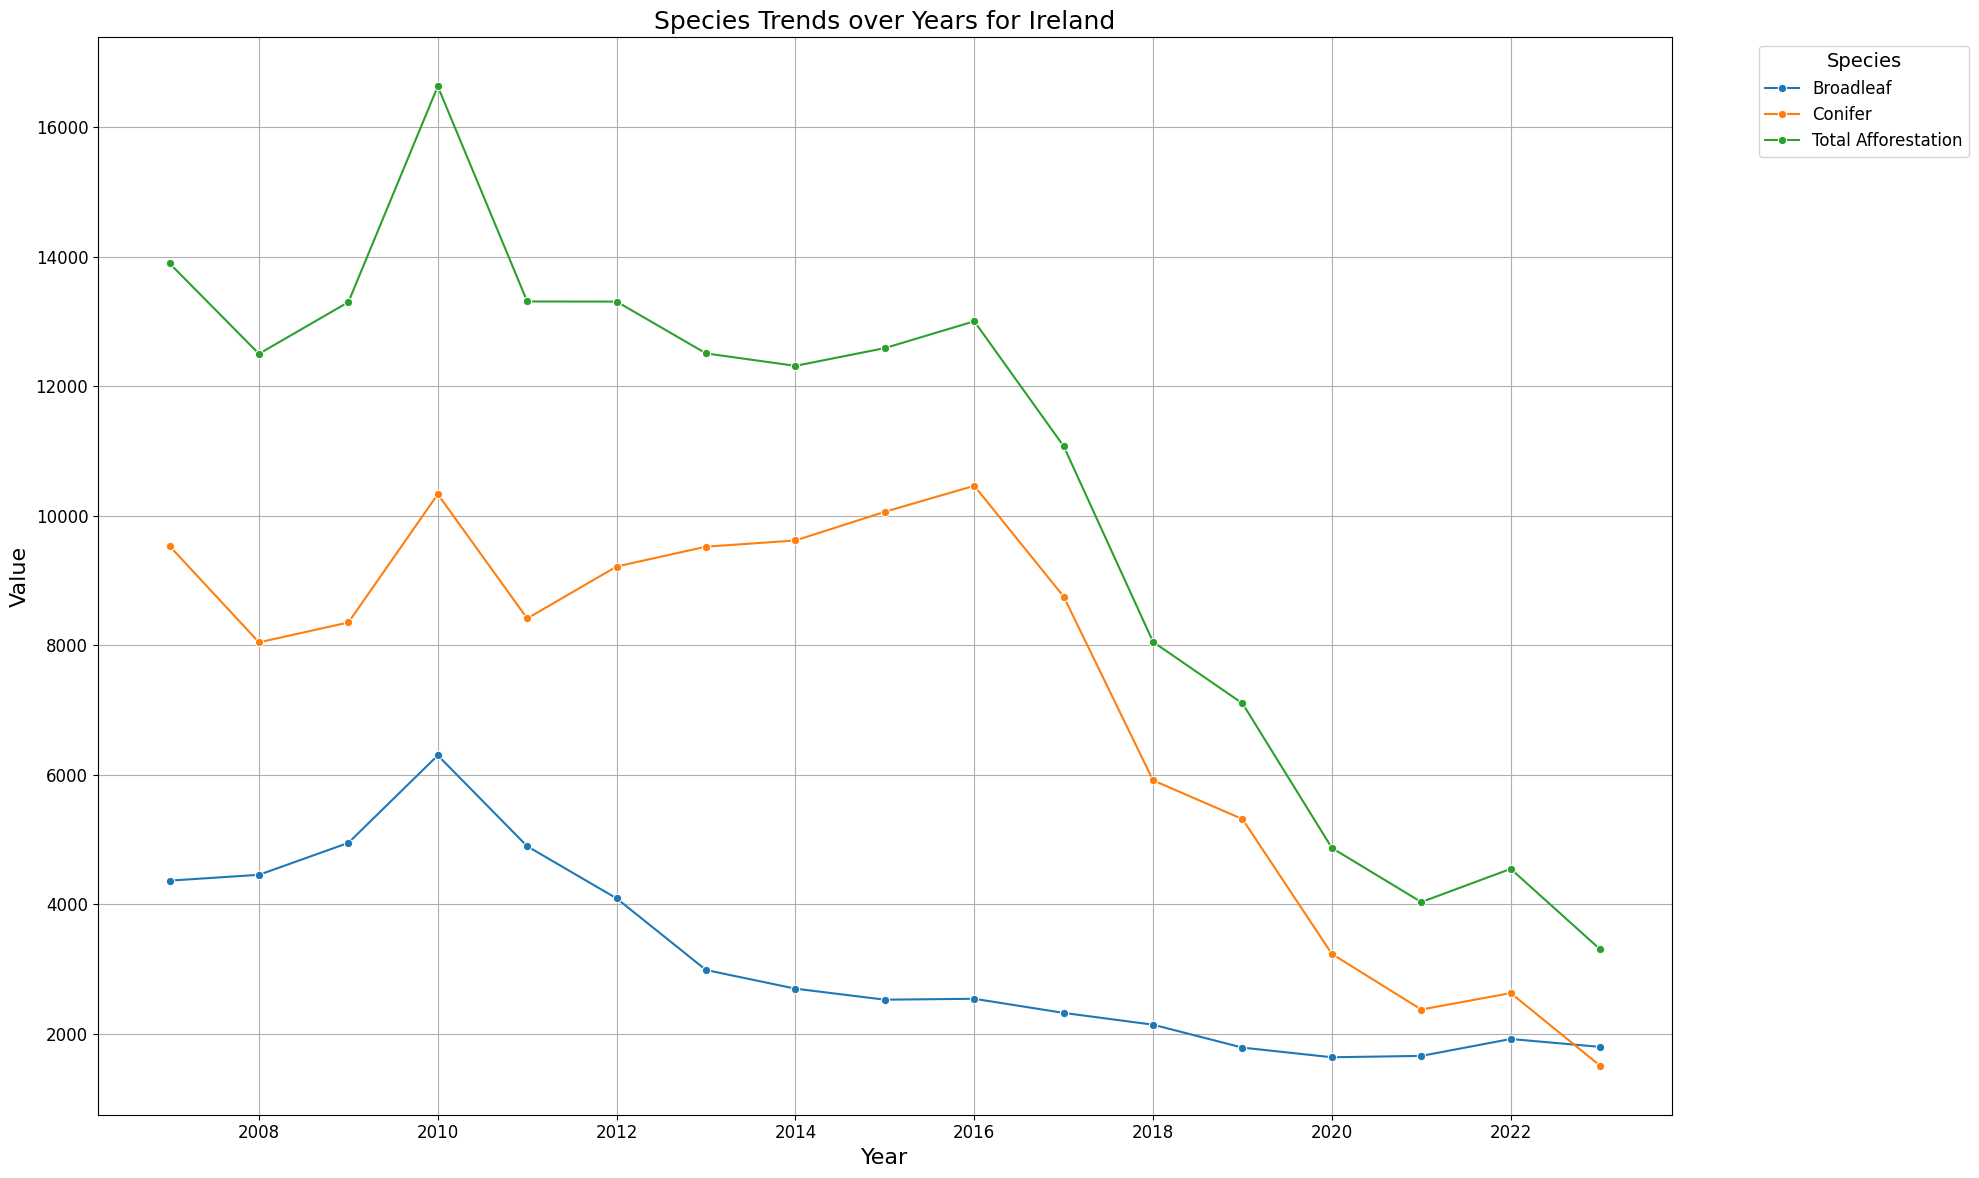

<Figure size 640x480 with 0 Axes>

In [227]:
plt.figure(figsize=(20, 12))
sns.lineplot(x='Year', y='VALUE', hue='Species', data=species_trends_ireland, marker='o')
plt.title('Species Trends over Years for Ireland')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()
# Save the plot
species_trends_ireland_path = os.path.join(outputs_dir, 'species_trends_ireland.png')
plt.savefig(species_trends_ireland_path)

I wanted to run it directly to see if there was a correlation between forest owner and the species being planted.

https://stackoverflow.com/questions/60799900/for-loop-with-dictionary-and-if-condition
https://pandas.pydata.org/docs/reference/api/pandas.Series.unique.html
https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features


In [228]:
# Now that I've done some analysis, I want to further explore using a linear regression model and to see if I can predict afforestation values based on year, species, forest owner, and county.
# Now to prepare the data for modeling.
model_data = data.copy()
# Encode categorical variables
model_data = pd.get_dummies(model_data, columns=['Species', 'Forest Owner', 'County'])  # Include all dummies
# Define features and target variable
X = model_data.drop(columns=['VALUE', 'Year', 'Statistic Label', 'UNIT'])  # Exclude 'Year', and non-numeric columns
y = model_data['VALUE']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 265588.4241452136
R-squared: 0.4390715929071859


As R-squared is 0.439, there is no correlation between the type of tree species being planted and forest owner.

Can the model predict 2030 afforestation hectarage?

In [229]:
# Now to see if the model can predict afforestation values for a specific year, species, forest owner, and county. Given that Ireland is aiming for 8,000 hectares of new afforestation annually by 2030, I will use this as a test case.

# Get unique species and forest owners from the data
unique_species = sorted(data['Species'].unique())
unique_forest_owners = sorted(data['Forest Owner'].unique())

print("\nUnique Species in dataset:")
print(unique_species)
print("\nUnique Forest Owners in dataset:")
print(unique_forest_owners)


Unique Species in dataset:
['Broadleaf', 'Conifer', 'Total Afforestation']

Unique Forest Owners in dataset:
['Farmer', 'Non-Farmer', 'Public Sector', 'Total Afforestation']


Creating the test case.

In [230]:
# Build test case for total afforestation in Ireland for 2030
test_case = {}

# Set species to 'Total Afforestation'
for species in unique_species:
    col_name = f'Species_{species}'
    test_case[col_name] = 1 if species == 'Total Afforestation' else 0

# Set forest owner to 'Total Afforestation'
for owner in unique_forest_owners:
    col_name = f'Forest Owner_{owner}'
    test_case[col_name] = 1 if owner == 'Total Afforestation' else 0

# Set county to 'Ireland'
unique_counties = sorted(data[data['County'] != 'Ireland']['County'].unique())
for county in unique_counties:
    col_name = f'County_{county}'
    test_case[col_name] = 0
test_case['County_Ireland'] = 1  # Ireland is not in unique_counties, so add manually

# Ensure all model features are in the test case with default values of 0
for feature in X.columns:
    if feature not in test_case:
        test_case[feature] = 0

test_case_df = pd.DataFrame([test_case])
predicted_value = model.predict(test_case_df)
print(f"\nPredicted total afforestation value for Ireland in 2030: {predicted_value[0]:.2f} hectares")
if predicted_value[0] >= 8000:
    print("The predicted value meets or exceeds the target of 8000 hectares per year.")
else:
    print("The predicted value is below the target of 8000 hectares per year.")


Predicted total afforestation value for Ireland in 2030: 2266.19 hectares
The predicted value is below the target of 8000 hectares per year.


### Explanation of Ireland Prediction

In the dataset, 'Ireland' is not just the sum of individual counties—it's a separate category provided by the CSO, where its VALUE represents the **national total afforestation**. This is why predicting for `County_Ireland = 1` is done: the model is trained on historical national totals and directly predicts the future total for Ireland as a whole.

To verify: Ireland's values in the data match the sums of all counties for the same year, species, and forest owner combinations. Using the Ireland dummy ensures we're predicting the aggregate, not summing individual county predictions (which could miss interactions in the model).

### But where am I getting these values from?

Ireland has a goal to increase National Forest Cover from 11.6 % (in 2024) to 18 % by 2050, to offset carbon emissions. This will require a National afforestation value of 8000 hectares per annum.

References for afforestation requirements:

- [Citizens Information - Afforestation Scheme](https://www.citizensinformation.ie/en/environment/land/afforestation-scheme/) 
- [Gov.ie - Forestry](https://www.gov.ie/en/department-of-agriculture-food-and-the-marine/press-releases/shared-national-vision-for-forestry-2050-published/)
- [Gov.ie - Ireland's Forestry Strategy](https://www.gov.ie/en/department-of-agriculture-food-and-the-marine/publications/irelands-forest-strategy-2023-2030/)
- [Forestry Services - Planting Rates](https://forestryservices.ie/planting-rates-must-exceed-8000ha-per-year/)
- [Independent.ie - Forestry](https://www.independent.ie/farming/forestry-enviro/forestry-planting-rates-must-exceed-8000ha-per-year-to-meet-climate-targets-epa/a1011415871.html)
- [Coillte](https://www.coillte.ie/coillte-launches-new-forestry-strategic-vision-to-optimise-its-contribution-to-irelands-climate-targets/#:~:text=28m%20tonnes%20of%20CO2,which%20will%20be%20native%20woodlands) (Non-Farmer private owner - but also kind of a public body) aims to plant 100,000 hectares of forest by 2050.

# END